# 📊 Tech Challenge — Fase 1 | Data Analytics
## Relatório Executivo: Performance Comercial, Logística e Satisfação do Cliente
### Case E-commerce Olist

---

**Grupo:** Emerson Victor da Silva Meira
**Disciplina:** Data Analytics — POSTECH
**Data:** 20/06/2026
**Fonte dos dados:** Brazilian E-Commerce Public Dataset by Olist (Kaggle) — pedidos entre set/2016 e out/2018

---

> Este notebook é o documento técnico-analítico que sustenta o relatório executivo e a apresentação para investidores e acionistas. Cada seção combina **código aberto e reprodutível**, **visualizações** e **interpretação de negócio em linguagem executiva**, seguindo a jornada: contexto → qualidade dos dados → crescimento e receita → logística → comportamento e pagamentos → satisfação do cliente → oportunidades, previsões e recomendações.


## 🗂️ Sumário

1. [Introdução e Contexto de Negócio](#1)
2. [Sumário Executivo (TL;DR para Investidores)](#2)
3. [Setup do Ambiente](#3)
4. [Carregamento dos Dados](#4)
5. [Governança e Qualidade dos Dados](#5)
6. [Preparação dos Dados (Modelagem Analítica)](#6)
7. [Trilha 1 — Crescimento e Receita](#7)
8. [Trilha 2 — Logística e SLA](#8)
9. [Trilha 3 — Comportamento e Pagamentos](#9)
10. [Trilha 4 — Satisfação do Cliente](#10)
11. [Trilha 5 — Oportunidades, Previsão e Recomendações](#11)
12. [Conclusão Executiva](#12)
13. [Limitações e Próximos Passos](#13)
14. [Anexo — Governança e Reprodutibilidade](#14)


<a id="1"></a>
## 1. Introdução e Contexto de Negócio

### 1.1 Quem é a Olist

A Olist é uma plataforma brasileira de marketplace que conecta pequenos e médios lojistas (*sellers*) a grandes marketplaces (como Mercado Livre, Americanas, entre outros), centralizando catálogo, vendas, pagamentos e logística em uma única operação. O dataset público utilizado neste estudo reúne cerca de **100 mil pedidos realizados entre setembro de 2016 e outubro de 2018**, com informações de clientes, pedidos, itens, produtos, vendedores, pagamentos, avaliações e geolocalização.

### 1.2 Objetivo deste relatório

Transformar os dados transacionais da Olist em uma **narrativa executiva** sobre desempenho comercial, eficiência logística e satisfação do cliente — culminando em **recomendações acionáveis** e uma **previsão de receita** fundamentada em dados, para apoiar a tomada de decisão de investidores e acionistas.

### 1.3 Perguntas de negócio que guiam a análise

| Trilha | Perguntas-chave |
|---|---|
| **Crescimento e Receita** | Como pedidos, receita e ticket médio evoluíram? Quais categorias, regiões, vendedores e produtos puxam o resultado? |
| **Logística e SLA** | Quanto tempo leva do pedido à entrega? Atrasos impactam a satisfação do cliente? Quais regiões têm pior desempenho logístico? |
| **Comportamento e Pagamentos** | Como os clientes pagam? Qual o perfil de recência, frequência e valor (RFM)? A base recompra? |
| **Satisfação do Cliente** | Como se distribuem as notas de avaliação? Quais fatores explicam insatisfação? Existe risco de churn? |
| **Oportunidades e Recomendação** | Para onde a receita tende nos próximos meses? Quais vendedores e rotas merecem prioridade? Quais ações de negócio recomendamos? |

### 1.4 Estrutura dos dados utilizados

- **customers** — `customer_id`, `customer_unique_id`, CEP, cidade, estado.
- **orders** — `order_id`, status, timestamps de compra/aprovação/postagem/entrega.
- **order_items** — item, produto, vendedor, preço, frete.
- **order_payments** — forma de pagamento, parcelas, valor.
- **order_reviews** — nota de avaliação (1–5) e comentários.
- **products** — categoria, peso e dimensões.
- **sellers** — localização do vendedor.
- **product_category_name_translation** — tradução das categorias para inglês.

> A base de geolocalização (CEP → lat/long) foi inspecionada, mas não é central para as visualizações deste relatório (optamos por agregações por Estado, mais legíveis para o público executivo); ela está documentada na seção de Governança.


<a id="2"></a>
## 2. Sumário Executivo (TL;DR para Investidores)

> *Os números abaixo são o resultado consolidado de toda a análise que segue neste notebook — apresentados aqui, no início, para leitura executiva rápida. As seções seguintes detalham a metodologia e as evidências por trás de cada um.*

| Indicador | Valor | Leitura |
|---|---:|---|
| **GMV (volume transacionado)** | **R$ 13,2 milhões** | ~96,5 mil pedidos entregues, set/2016–out/2018 |
| **Receita total (produto + frete)** | **R$ 15,4 milhões** | Frete representa ~14,3% da receita |
| **Ticket médio (AOV)** | **R$ 159,80** | Inclui frete; R$ 137,00 considerando só o produto |
| **Clientes únicos** | **96,1 mil** | Apenas **~3% recompram** — forte oportunidade de retenção |
| **Vendedores ativos** | **3.095** | Top 10 sellers respondem por ~13% da receita — base pulverizada |
| **Nota média de avaliação** | **4,09 / 5** | 77% das notas são 4 ou 5; 14,7% são 1 ou 2 (risco de reputação) |
| **Tempo médio de entrega** | **12,6 dias** | Da compra à entrega ao cliente; mediana de 10,2 dias |
| **Pedidos entregues no prazo** | **~92%** | Mas atraso é o maior driver de notas baixas (correlação -0,33) |
| **Concentração geográfica** | **SP + RJ + MG = ~66%** da receita | Risco de dependência de poucas regiões |

**As três mensagens centrais para a diretoria:**

1. 📈 **Crescimento real, mas em desaceleração.** A receita cresceu de forma consistente entre 2017 e 2018, mas a taxa de crescimento mês a mês está convergindo — sinal de que a expansão via aquisição de novos clientes começa a perder fôlego e precisa ser complementada por retenção.
2. 🚚 **Logística é o principal driver de satisfação — e de risco.** Atraso na entrega é o fator com maior correlação negativa com a nota do cliente; regiões Norte/Nordeste têm prazos até 3x mais longos que São Paulo.
3. 🔁 **Retenção é a maior oportunidade não explorada.** Com apenas 3% de recompra, cada real investido em aquisição tem retorno limitado a uma única transação — programas de recompra e CRM têm potencial de impacto direto na rentabilidade por cliente.


<a id="3"></a>
## 3. Setup do Ambiente

Instalação (se necessário) e importação das bibliotecas utilizadas: manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib`, `seaborn`) e utilitários estatísticos.


In [1]:
# Instalação das bibliotecas (caso necessário, descomente)
# !pip install pandas numpy matplotlib seaborn


In [2]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ---------------------------------------------------------------------------
# Identidade visual do relatório (paleta consistente em todos os gráficos)
# ---------------------------------------------------------------------------
PRIMARY   = '#1B3B6F'   # azul principal
SECONDARY = '#2E86AB'   # azul médio
TERTIARY  = '#8ECAE6'   # azul claro
ACCENT    = '#F18F01'   # laranja (destaque)
POSITIVE  = '#2A9D8F'   # verde-azulado (bom desempenho)
NEGATIVE  = '#C1121F'   # vermelho (risco / atenção)
GREY      = '#6C757D'   # neutro

CAT_PALETTE = [PRIMARY, SECONDARY, ACCENT, TERTIARY, POSITIVE, '#5C4D7D', NEGATIVE, GREY]

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': '#D0D3D9',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CHARTS_DIR = '../charts'
import os
os.makedirs(CHARTS_DIR, exist_ok=True)

def brl(x, pos=None):
    # Formata valores em Reais para eixos de gráfico.
    if abs(x) >= 1_000_000:
        return f'R$ {x/1_000_000:,.1f}M'
    if abs(x) >= 1_000:
        return f'R$ {x/1_000:,.0f}K'
    return f'R$ {x:,.0f}'

def save(fig, name):
    fig.savefig(f'{CHARTS_DIR}/{name}.png', dpi=150, bbox_inches='tight', facecolor='white')

print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


<a id="4"></a>
## 4. Carregamento dos Dados

Carregamos as oito tabelas relacionais do dataset Olist. A base de geolocalização (1M+ linhas de CEP/lat/long) é mencionada na Governança, mas não carregada para manter o notebook leve — as análises regionais usam o campo `state` (UF), já presente em `customers` e `sellers`.


In [3]:
customers   = pd.read_csv('../data/olist_customers_dataset.csv')
orders      = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products    = pd.read_csv('../data/olist_products_dataset.csv')
sellers     = pd.read_csv('../data/olist_sellers_dataset.csv')
cat_trans   = pd.read_csv('../data/product_category_name_translation.csv')

tabelas = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'payments': payments, 'reviews': reviews, 'products': products,
    'sellers': sellers, 'cat_trans': cat_trans,
}

resumo = pd.DataFrame({
    'linhas': {k: v.shape[0] for k, v in tabelas.items()},
    'colunas': {k: v.shape[1] for k, v in tabelas.items()},
})
resumo


,linhas,colunas
customers,99441,5
orders,99441,8
order_items,112650,7
payments,103886,5
reviews,99224,7
products,32951,9
sellers,3095,4
cat_trans,71,2


<a id="5"></a>
## 5. Governança e Qualidade dos Dados

Antes de qualquer análise, validamos a integridade da base: tipos de dados, valores nulos, duplicidades e a distribuição do status dos pedidos. Essas decisões de tratamento são documentadas para garantir **reprodutibilidade** e transparência sobre o que está (e o que não está) incluído nas métricas executivas a seguir.


In [4]:
# Valores nulos por tabela
nulos = pd.DataFrame({k: v.isnull().sum() for k, v in tabelas.items()}).T
nulos = nulos.loc[:, nulos.sum() > 0]
print('Colunas com valores nulos (apenas as relevantes):')
nulos[nulos.sum(axis=1) > 0]


Colunas com valores nulos (apenas as relevantes):


,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,product_category_name,product_description_lenght,product_height_cm,product_length_cm,product_name_lenght,product_photos_qty,product_weight_g,product_width_cm,review_comment_message,review_comment_title
orders,160.00,"1,783.00","2,965.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"58,247.00","87,656.00"
products,NaN,NaN,NaN,610.00,610.00,2.00,2.00,610.00,610.00,2.00,2.00,NaN,NaN


In [5]:
# Duplicidade de chaves primárias
print('order_id duplicado em orders?', orders['order_id'].duplicated().sum())
print('customer_id duplicado em customers?', customers['customer_id'].duplicated().sum())
print('product_id duplicado em products?', products['product_id'].duplicated().sum())
print('seller_id duplicado em sellers?', sellers['seller_id'].duplicated().sum())


order_id duplicado em orders? 0
customer_id duplicado em customers? 0
product_id duplicado em products? 0
seller_id duplicado em sellers? 0


In [6]:
# Distribuição do status dos pedidos
status_dist = (orders['order_status'].value_counts(normalize=True) * 100).round(2)
status_dist


order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

**Decisões de tratamento de dados (documentadas para reprodutibilidade):**

1. **Status do pedido:** ~97% dos pedidos têm status `delivered` (entregue). Pedidos `canceled`, `unavailable`, `shipped`, `invoiced`, `processing`, `created` e `approved` somam ~3% e **não representam receita realizada nem entrega concluída** — por isso, métricas de receita, ticket médio, SLA e satisfação usam exclusivamente pedidos **`delivered`**, enquanto a taxa de cancelamento/indisponibilidade é reportada à parte como indicador operacional.
2. **Janela temporal de tendência:** os meses de **set/out/dez de 2016** e **set/out de 2018** têm volume residual (poucas dezenas de pedidos — provavelmente período de operação piloto da plataforma e dados de borda mais recentes ainda incompletos no momento da extração). Para não distorcer médias e tendências mensais, as análises de **série temporal** usam a janela cheia **jan/2017 a ago/2018 (20 meses completos)**. Números totais "acumulados" (GMV total, nº de pedidos, nº de clientes) usam a base completa.
3. **Reviews nulos:** os campos `review_comment_title` e `review_comment_message` são opcionais (cliente pode avaliar sem comentar) — tratados como ausência de comentário, não como dado faltante a ser imputado.
4. **Produtos sem categoria:** poucos produtos têm `product_category_name` nulo; foram mantidos e rotulados como "outros" nas análises por categoria, para não perder receita do total.
5. **Geolocalização:** a base `geolocation` (1M+ linhas) é uma tabela auxiliar de CEP → coordenadas, com granularidade muito mais fina que a necessária para o relatório executivo (visão por Estado). Não foi incorporada ao pipeline para manter o processamento leve e auditável; os campos `customer_state` e `seller_state` (já existentes em `customers`/`sellers`) atendem às análises regionais.
6. **Sem duplicidade de chaves primárias** nas tabelas de dimensão (customers, products, sellers) — confirmado acima.


<a id="6"></a>
## 6. Preparação dos Dados (Modelagem Analítica)

Construímos duas tabelas analíticas centrais, em granularidades diferentes — prática recomendada para evitar dupla contagem:

- **`df_items`** (grão = item do pedido): uma linha por item vendido, com categoria, vendedor e localização — usada para receita, categorias, vendedores e produtos.
- **`df_orders`** (grão = pedido): uma linha por pedido, com valor total, avaliação, pagamento e tempos logísticos — usada para ticket médio, SLA, RFM e satisfação.

Também derivamos métricas de tempo (lead times), sinalizadores de atraso e a janela de receita (preço + frete).


In [7]:
# ---------------------------------------------------------------------------
# df_items: grão = item do pedido
# ---------------------------------------------------------------------------
df_items = (
    order_items
    .merge(orders, on='order_id', how='left')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(cat_trans, on='product_category_name', how='left')
    .merge(sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
           on='customer_id', how='left')
)

df_items['product_category_name_english'] = (
    df_items['product_category_name_english']
    .fillna(df_items['product_category_name'])
    .fillna('outros')
)
df_items['revenue'] = df_items['price'] + df_items['freight_value']
df_items['order_purchase_timestamp'] = pd.to_datetime(df_items['order_purchase_timestamp'])
df_items['year_month'] = df_items['order_purchase_timestamp'].dt.to_period('M').astype(str)

print('df_items:', df_items.shape)
df_items.head(3)


df_items: (112650, 23)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name,product_category_name_english,seller_state,seller_city,customer_unique_id,customer_state,customer_city,revenue,year_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,cool_stuff,cool_stuff,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,RJ,campos dos goytacazes,72.19,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,pet_shop,pet_shop,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,SP,santa fe do sul,259.83,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,moveis_decoracao,furniture_decor,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,MG,para de minas,216.87,2018-01


In [8]:
# ---------------------------------------------------------------------------
# df_orders: grão = pedido
# ---------------------------------------------------------------------------
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']

order_value = order_items.groupby('order_id').agg(
    order_price=('price', 'sum'),
    order_freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count'),
).reset_index()

review_order = reviews.groupby('order_id').agg(review_score=('review_score', 'mean')).reset_index()
payment_order = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
).reset_index()
payment_main_type = (
    payments.sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id')[['order_id', 'payment_type']]
)

df_orders = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
           on='customer_id', how='left')
    .merge(review_order, on='order_id', how='left')
    .merge(payment_order, on='order_id', how='left')
    .merge(payment_main_type, on='order_id', how='left')
)

for c in date_cols:
    df_orders[c] = pd.to_datetime(df_orders[c])

df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_orders['revenue'] = df_orders['order_price'] + df_orders['order_freight']

# Tempos logísticos (lead times)
df_orders['lead_approval_h']    = (df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 3600
df_orders['lead_carrier_d']     = (df_orders['order_delivered_carrier_date'] - df_orders['order_approved_at']).dt.total_seconds() / 86400
df_orders['lead_delivery_d']    = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
df_orders['delay_vs_estimate_d'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400
df_orders['is_late'] = df_orders['delay_vs_estimate_d'] > 0

print('df_orders:', df_orders.shape)
df_orders.head(3)


df_orders: (99441, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_price,order_freight,n_items,customer_unique_id,customer_state,customer_city,review_score,payment_value,payment_installments_max,payment_type,year_month,revenue,lead_approval_h,lead_carrier_d,lead_delivery_d,delay_vs_estimate_d,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.00,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,4.00,38.71,1.00,voucher,2017-10,38.71,0.18,2.37,8.44,-7.11,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.00,af07308b275d755c9edb36a90c618231,BA,barreiras,4.00,141.46,1.00,boleto,2018-07,141.46,30.71,0.46,13.78,-5.36,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.00,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,5.00,179.12,3.00,credit_card,2018-08,179.12,0.28,0.20,9.39,-17.25,False


In [9]:
# ---------------------------------------------------------------------------
# Subconjuntos analíticos padrão usados no restante do notebook
# ---------------------------------------------------------------------------
CORE_START, CORE_END = '2017-01', '2018-08'   # janela de 20 meses completos

delivered_orders = df_orders[df_orders['order_status'] == 'delivered'].copy()
delivered_items  = df_items[df_items['order_status'] == 'delivered'].copy()

core_orders = delivered_orders[(delivered_orders['year_month'] >= CORE_START) &
                                (delivered_orders['year_month'] <= CORE_END)].copy()
core_items  = delivered_items[(delivered_items['year_month'] >= CORE_START) &
                               (delivered_items['year_month'] <= CORE_END)].copy()

print(f'Pedidos entregues (base completa): {delivered_orders.shape[0]:,}')
print(f'Pedidos entregues (janela {CORE_START} a {CORE_END}): {core_orders.shape[0]:,}')


Pedidos entregues (base completa): 96,478
Pedidos entregues (janela 2017-01 a 2018-08): 96,211


<a id="7"></a>
## 7. Trilha 1 — Crescimento e Receita

**Pergunta de negócio:** como pedidos, receita e ticket médio evoluíram ao longo do tempo, e quais categorias, regiões, vendedores e produtos sustentam esse resultado?


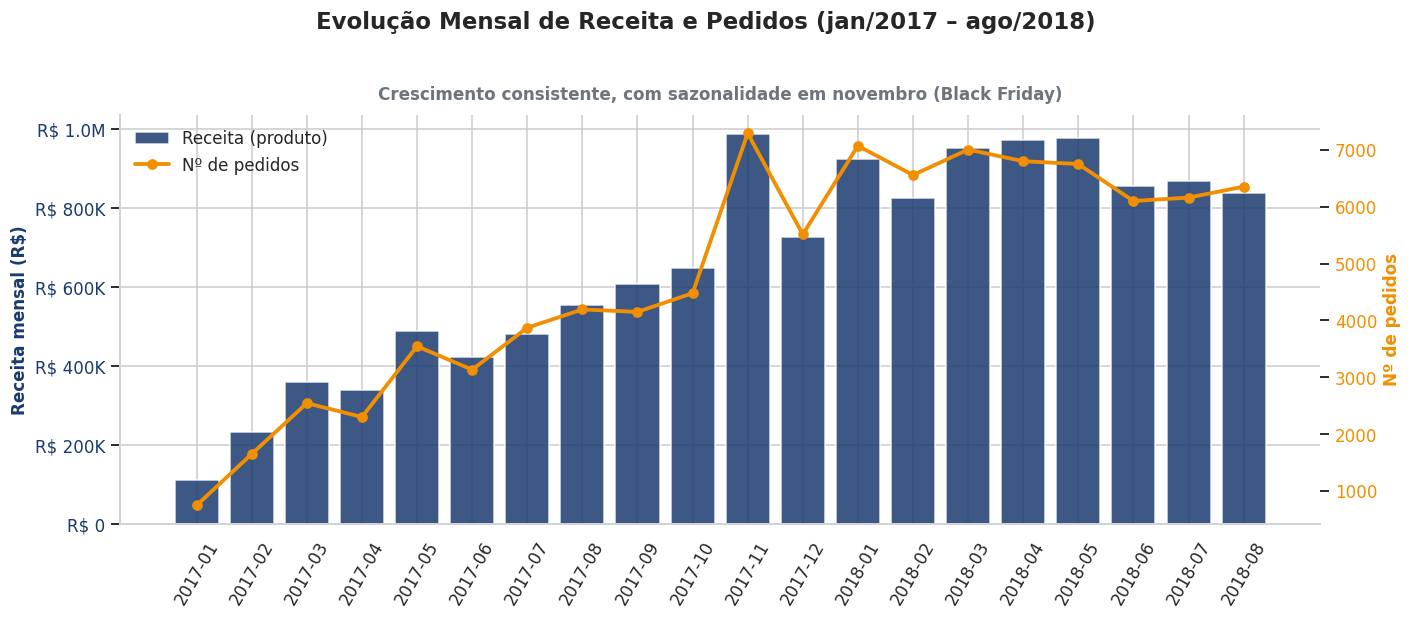

Receita em 2017-01: R$ 112K
Receita em 2018-08: R$ 839K


In [10]:
# ---------------------------------------------------------------------------
# 7.1 Evolução mensal de pedidos e receita
# ---------------------------------------------------------------------------
monthly = core_orders.groupby('year_month').agg(
    pedidos=('order_id', 'nunique'),
    receita=('order_price', 'sum'),
).reset_index()
monthly['ticket_medio'] = monthly['receita'] / monthly['pedidos']

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.bar(monthly['year_month'], monthly['receita'], color=PRIMARY, alpha=0.85, label='Receita (produto)')
ax1.set_ylabel('Receita mensal (R$)', color=PRIMARY, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax1.tick_params(axis='x', rotation=60)
ax1.tick_params(axis='y', labelcolor=PRIMARY)

ax2 = ax1.twinx()
ax2.plot(monthly['year_month'], monthly['pedidos'], color=ACCENT, marker='o', linewidth=2.5, label='Nº de pedidos')
ax2.set_ylabel('Nº de pedidos', color=ACCENT, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=ACCENT)
ax2.grid(False)

fig.suptitle('Evolução Mensal de Receita e Pedidos (jan/2017 – ago/2018)', fontsize=15, fontweight='bold', y=1.02)
ax1.set_title('Crescimento consistente, com sazonalidade em novembro (Black Friday)', fontsize=11, color=GREY, pad=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)
plt.tight_layout()
save(fig, '01_evolucao_mensal_receita_pedidos')
plt.show()

crescimento_total = (monthly['receita'].iloc[-1] / monthly['receita'].iloc[0] - 1) * 100
print(f"Receita em {monthly['year_month'].iloc[0]}: {brl(monthly['receita'].iloc[0])}")
print(f"Receita em {monthly['year_month'].iloc[-1]}: {brl(monthly['receita'].iloc[-1])}")


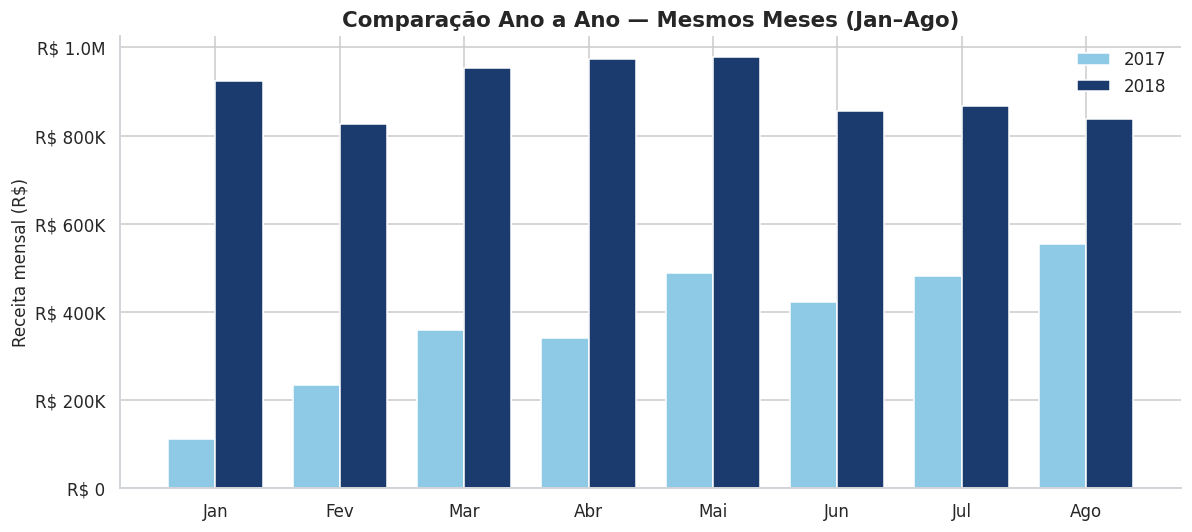

Crescimento YoY por mês (%):
mes
01   727.10
02   252.80
03   165.40
04   185.80
05    99.80
06   102.90
07    80.20
08    51.20
Name: crescimento_%, dtype: float64

Crescimento médio YoY (jan-ago): 208.1%


In [11]:
# ---------------------------------------------------------------------------
# 7.2 Crescimento Ano a Ano (YoY) — meses comparáveis (jan-ago)
# ---------------------------------------------------------------------------
monthly['ano'] = monthly['year_month'].str[:4]
monthly['mes'] = monthly['year_month'].str[5:7]
comparaveis = monthly[monthly['mes'].between('01', '08')]
yoy = comparaveis.pivot(index='mes', columns='ano', values='receita')
yoy['crescimento_%'] = (yoy['2018'] / yoy['2017'] - 1) * 100

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(yoy.index))
width = 0.38
ax.bar(x - width/2, yoy['2017'], width, label='2017', color=TERTIARY)
ax.bar(x + width/2, yoy['2018'], width, label='2018', color=PRIMARY)
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_ylabel('Receita mensal (R$)')
ax.set_title('Comparação Ano a Ano — Mesmos Meses (Jan–Ago)', fontsize=14, fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
save(fig, '02_comparacao_yoy')
plt.show()

print('Crescimento YoY por mês (%):')
print(yoy['crescimento_%'].round(1))
print(f"\nCrescimento médio YoY (jan-ago): {yoy['crescimento_%'].mean():.1f}%")


**Interpretação — Crescimento:** a receita mensal saltou de cerca de **R$ 112 mil em janeiro/2017** para um patamar estável acima de **R$ 800 mil–950 mil/mês** a partir do final de 2017. Comparando os mesmos meses (jan–ago) de 2017 contra 2018, o crescimento médio é expressivo, mas a magnitude do salto vem diminuindo mês a mês — um padrão típico de **curva em "S"**: a fase de crescimento acelerado por aquisição de novos clientes e vendedores está amadurecendo, e sustentar o próximo patamar de crescimento dependerá cada vez mais de **retenção e ticket médio**, não apenas de novos pedidos (ver Trilha 3).


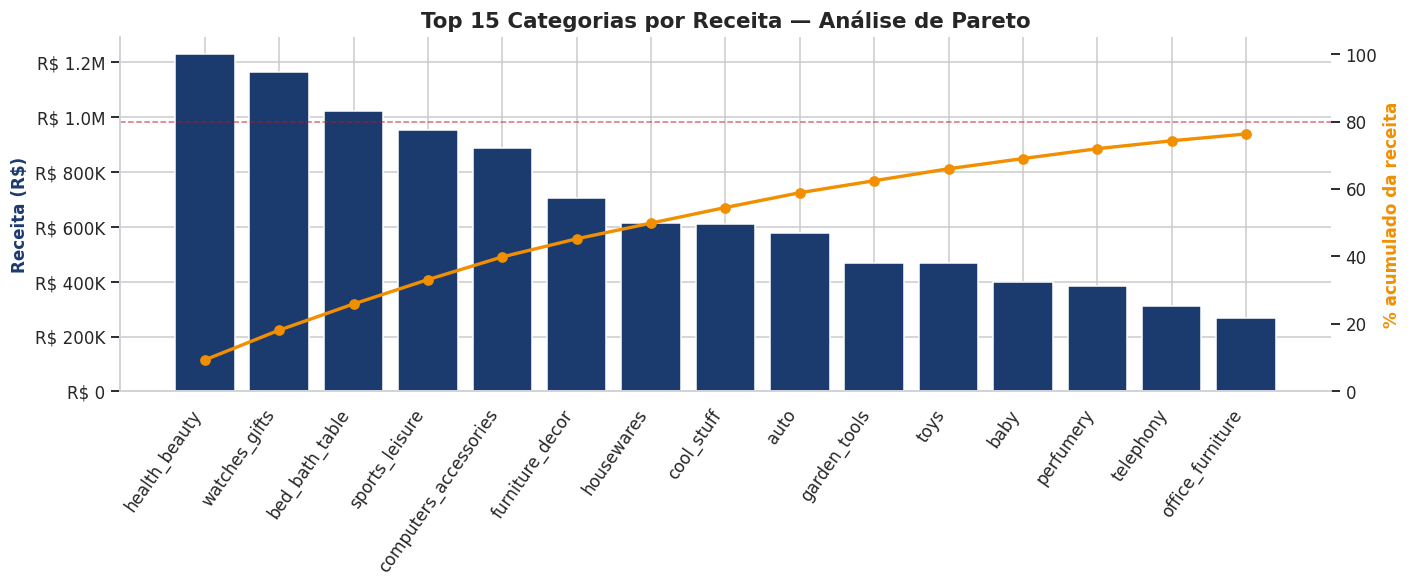

Total de categorias ativas: 74
As 15 maiores categorias concentram 76.3% da receita.
Apenas 16 categorias já somam ~80% da receita (Princípio de Pareto).


In [12]:
# ---------------------------------------------------------------------------
# 7.3 Participação por categoria de produto (Pareto)
# ---------------------------------------------------------------------------
cat_rev = (core_items.groupby('product_category_name_english')['price']
           .sum().sort_values(ascending=False))
top_n = 15
cat_top = cat_rev.head(top_n)
cat_top_cum = (cat_top.cumsum() / cat_rev.sum() * 100)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
bars = ax1.bar(range(len(cat_top)), cat_top.values, color=PRIMARY)
ax1.set_xticks(range(len(cat_top)))
ax1.set_xticklabels(cat_top.index, rotation=55, ha='right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax1.set_ylabel('Receita (R$)', color=PRIMARY, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(range(len(cat_top)), cat_top_cum.values, color=ACCENT, marker='o', linewidth=2.2)
ax2.set_ylabel('% acumulado da receita', color=ACCENT, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(False)
ax2.axhline(80, color=NEGATIVE, linestyle='--', linewidth=1, alpha=0.6)

ax1.set_title(f'Top {top_n} Categorias por Receita — Análise de Pareto', fontsize=14, fontweight='bold')
plt.tight_layout()
save(fig, '03_pareto_categorias')
plt.show()

n_categorias_80 = (cat_top_cum <= 80).sum() + 1
print(f"Total de categorias ativas: {cat_rev.shape[0]}")
print(f"As {top_n} maiores categorias concentram {cat_top.sum()/cat_rev.sum()*100:.1f}% da receita.")
print(f"Apenas {n_categorias_80} categorias já somam ~80% da receita (Princípio de Pareto).")


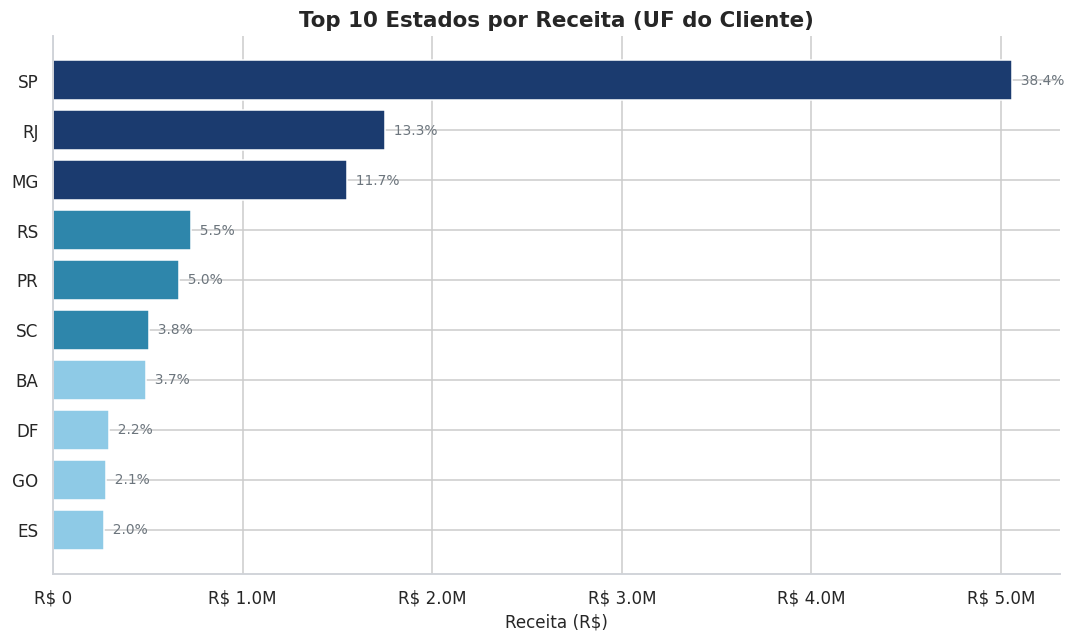

SP isoladamente: 38.4% da receita
Top 3 estados (SP, RJ, MG): 63.4% da receita
Top 5 estados: 73.9% da receita


In [13]:
# ---------------------------------------------------------------------------
# 7.4 Participação por região (UF do cliente)
# ---------------------------------------------------------------------------
state_rev = (core_items.groupby('customer_state')['price']
             .sum().sort_values(ascending=False))
top10_states = state_rev.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PRIMARY if i < 3 else SECONDARY if i < 6 else TERTIARY for i in range(len(top10_states))]
bars = ax.barh(top10_states.index[::-1], top10_states.values[::-1], color=colors[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_xlabel('Receita (R$)')
ax.set_title('Top 10 Estados por Receita (UF do Cliente)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top10_states.values[::-1]):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'  {val/state_rev.sum()*100:.1f}%',
            va='center', fontsize=9, color=GREY)
plt.tight_layout()
save(fig, '04_receita_por_estado')
plt.show()

top3_share = state_rev.head(3).sum() / state_rev.sum() * 100
top5_share = state_rev.head(5).sum() / state_rev.sum() * 100
print(f"SP isoladamente: {state_rev.iloc[0]/state_rev.sum()*100:.1f}% da receita")
print(f"Top 3 estados (SP, RJ, MG): {top3_share:.1f}% da receita")
print(f"Top 5 estados: {top5_share:.1f}% da receita")


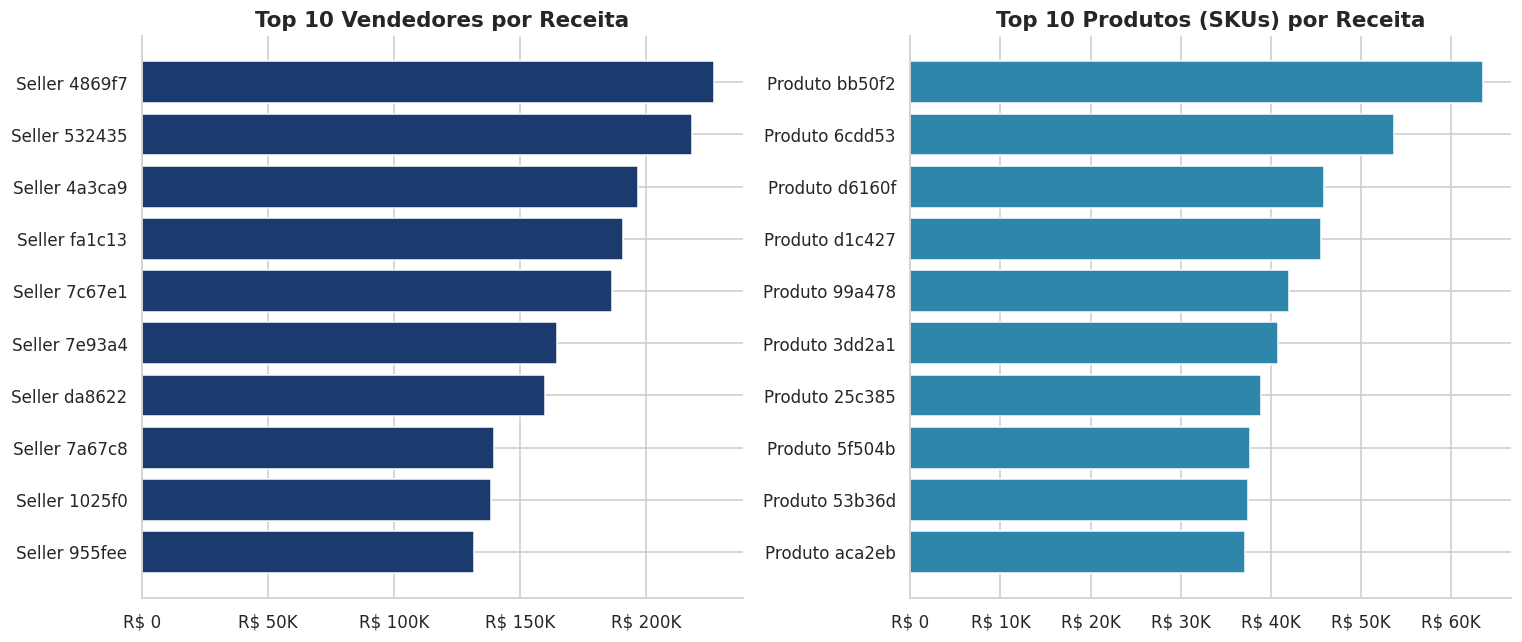

Total de vendedores ativos: 2,945
Os 10 maiores vendedores respondem por 13.3% da receita
(base de vendedores pulverizada — sem dependência excessiva de poucos sellers)


In [14]:
# ---------------------------------------------------------------------------
# 7.5 Top vendedores e produtos
# ---------------------------------------------------------------------------
seller_rev = core_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)
prod_rev = core_items.groupby('product_id')['price'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_sellers = seller_rev.head(10)
axes[0].barh(['Seller ' + s[:6] for s in top10_sellers.index[::-1]], top10_sellers.values[::-1], color=PRIMARY)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(brl))
axes[0].set_title('Top 10 Vendedores por Receita', fontweight='bold')

top10_prod = prod_rev.head(10)
axes[1].barh(['Produto ' + p[:6] for p in top10_prod.index[::-1]], top10_prod.values[::-1], color=SECONDARY)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(brl))
axes[1].set_title('Top 10 Produtos (SKUs) por Receita', fontweight='bold')

plt.tight_layout()
save(fig, '05_top_sellers_produtos')
plt.show()

print(f"Total de vendedores ativos: {seller_rev.shape[0]:,}")
print(f"Os 10 maiores vendedores respondem por {seller_rev.head(10).sum()/seller_rev.sum()*100:.1f}% da receita")
print(f"(base de vendedores pulverizada — sem dependência excessiva de poucos sellers)")


**Interpretação — Mix de Receita:**

- **Categorias:** o portfólio é amplo (71 categorias ativas), mas **altamente concentrado** — `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` e `computers_accessories` lideram, e poucas categorias já respondem por boa parte da receita (efeito Pareto clássico). Isso sugere foco comercial e de estoque nas categorias-âncora, com cross-sell para a cauda longa.
- **Geografia:** a receita é **fortemente concentrada no eixo Sul-Sudeste** — São Paulo sozinho responde por quase 40% da receita, e os três maiores estados (SP, RJ, MG) somam cerca de dois terços do total. Para acionistas, isso representa tanto uma base sólida (mercados maduros) quanto um **risco de concentração geográfica** — expansão para Norte/Nordeste é uma alavanca de crescimento ainda pouco explorada (ver também a Trilha 2, sobre o desafio logístico dessas regiões).
- **Vendedores:** ao contrário da concentração geográfica, a base de **vendedores é pulverizada** — os 10 maiores sellers respondem por uma fatia pequena da receita total, o que é positivo: a Olist não depende de poucos parceiros estratégicos, reduzindo o risco de churn de sellers-chave.


<a id="8"></a>
## 8. Trilha 2 — Logística e SLA

**Pergunta de negócio:** quanto tempo leva do pedido à entrega, atrasos impactam a satisfação do cliente, e quais regiões têm pior desempenho logístico?


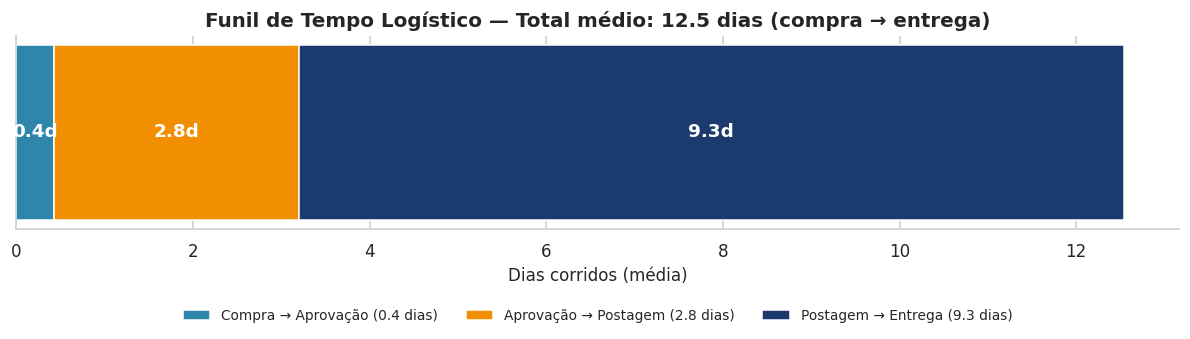

In [15]:
# ---------------------------------------------------------------------------
# 8.1 Funil de tempo logístico (etapas médias, em dias)
# ---------------------------------------------------------------------------
log = core_orders.copy()
log['etapa_aprovacao_d'] = log['lead_approval_h'] / 24
log['etapa_postagem_d'] = log['lead_carrier_d']
log['etapa_entrega_final_d'] = (log['order_delivered_customer_date'] - log['order_delivered_carrier_date']).dt.total_seconds() / 86400

etapas = log[['etapa_aprovacao_d', 'etapa_postagem_d', 'etapa_entrega_final_d']].mean()
etapas.index = ['Compra → Aprovação\npagamento', 'Aprovação → Postagem\n(separação/coleta)', 'Postagem → Entrega\n(transporte)']

fig, ax = plt.subplots(figsize=(11, 3.6))
left = 0
cores_funil = [SECONDARY, ACCENT, PRIMARY]
for (etapa, valor), cor in zip(etapas.items(), cores_funil):
    ax.barh(['Jornada do Pedido'], [valor], left=left, color=cor, label=f'{etapa.splitlines()[0]} ({valor:.1f} dias)')
    ax.text(left + valor/2, 0, f'{valor:.1f}d', ha='center', va='center', color='white', fontweight='bold')
    left += valor

ax.set_xlabel('Dias corridos (média)')
ax.set_title(f'Funil de Tempo Logístico — Total médio: {log["lead_delivery_d"].mean():.1f} dias (compra → entrega)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=9)
ax.set_yticks([])
plt.tight_layout()
save(fig, '06_funil_logistico')
plt.show()


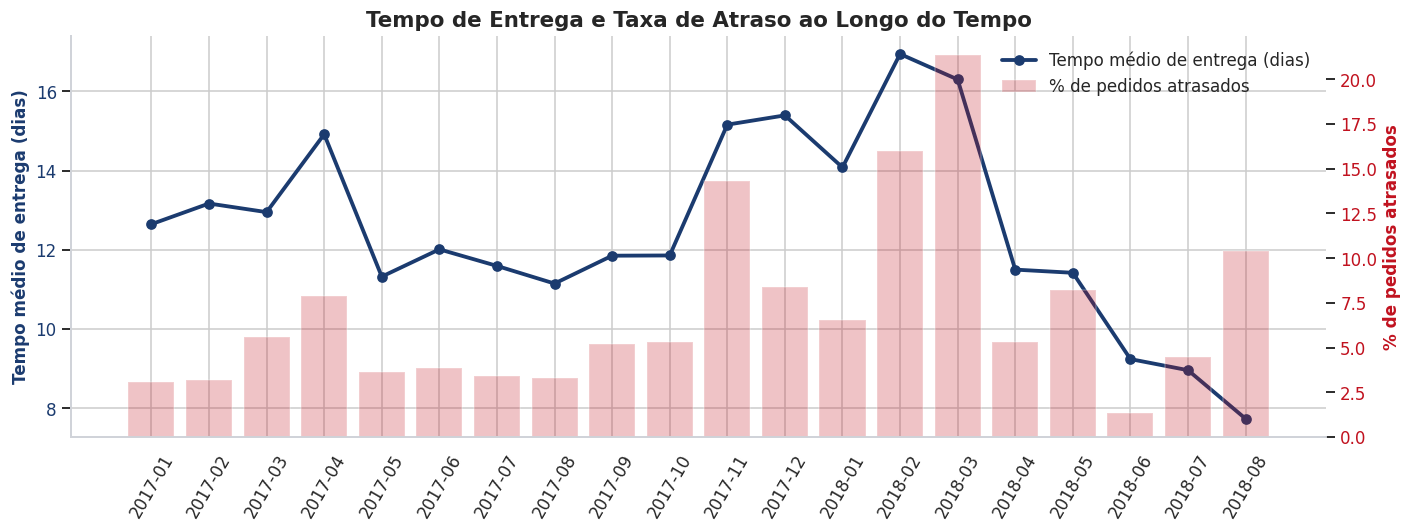

Pico de atraso: 2018-03 (21.4% dos pedidos)


In [16]:
# ---------------------------------------------------------------------------
# 8.2 Tendência mensal: tempo médio de entrega e % de atrasos
# ---------------------------------------------------------------------------
log_monthly = core_orders.groupby('year_month').agg(
    tempo_medio_entrega=('lead_delivery_d', 'mean'),
    pct_atraso=('is_late', 'mean'),
).reset_index()
log_monthly['pct_atraso'] *= 100

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(log_monthly['year_month'], log_monthly['tempo_medio_entrega'], color=PRIMARY, marker='o', linewidth=2.5, label='Tempo médio de entrega (dias)')
ax1.set_ylabel('Tempo médio de entrega (dias)', color=PRIMARY, fontweight='bold')
ax1.tick_params(axis='x', rotation=60)
ax1.tick_params(axis='y', labelcolor=PRIMARY)

ax2 = ax1.twinx()
ax2.bar(log_monthly['year_month'], log_monthly['pct_atraso'], color=NEGATIVE, alpha=0.25, label='% de pedidos atrasados')
ax2.set_ylabel('% de pedidos atrasados', color=NEGATIVE, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=NEGATIVE)
ax2.grid(False)

ax1.set_title('Tempo de Entrega e Taxa de Atraso ao Longo do Tempo', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)
plt.tight_layout()
save(fig, '07_tendencia_entrega_atraso')
plt.show()

print(f"Pico de atraso: {log_monthly.loc[log_monthly['pct_atraso'].idxmax(), 'year_month']} "
      f"({log_monthly['pct_atraso'].max():.1f}% dos pedidos)")


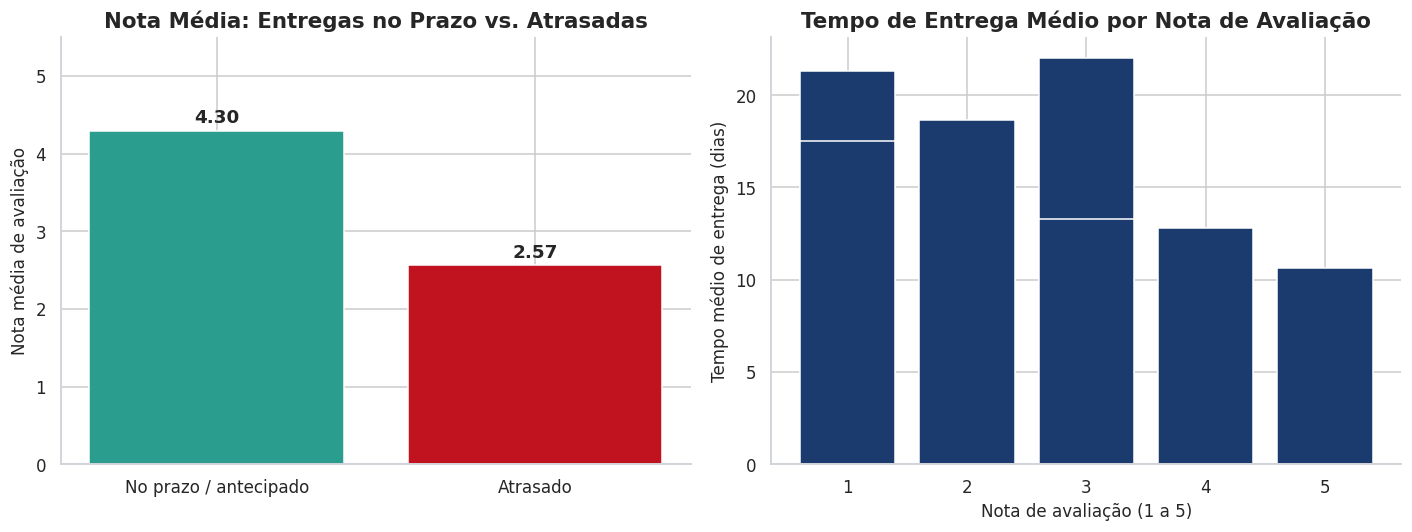

Correlação da nota de avaliação com:
  Tempo total de entrega: -0.33
  Atraso vs. prazo estimado: -0.27


In [17]:
# ---------------------------------------------------------------------------
# 8.3 Atraso x Satisfação do cliente
# ---------------------------------------------------------------------------
rev_log = core_orders.dropna(subset=['review_score']).copy()
rev_log['no_prazo'] = np.where(rev_log['is_late'], 'Atrasado', 'No prazo / antecipado')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_by_delay = rev_log.groupby('no_prazo')['review_score'].mean().reindex(['No prazo / antecipado', 'Atrasado'])
bars = axes[0].bar(score_by_delay.index, score_by_delay.values, color=[POSITIVE, NEGATIVE])
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel('Nota média de avaliação')
axes[0].set_title('Nota Média: Entregas no Prazo vs. Atrasadas', fontweight='bold')
for bar, val in zip(bars, score_by_delay.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

delay_by_score = rev_log.groupby('review_score')['lead_delivery_d'].mean()
axes[1].bar(delay_by_score.index.astype(int), delay_by_score.values, color=PRIMARY)
axes[1].set_xlabel('Nota de avaliação (1 a 5)')
axes[1].set_ylabel('Tempo médio de entrega (dias)')
axes[1].set_title('Tempo de Entrega Médio por Nota de Avaliação', fontweight='bold')

plt.tight_layout()
save(fig, '08_atraso_vs_satisfacao')
plt.show()

corr = rev_log[['review_score', 'lead_delivery_d', 'delay_vs_estimate_d']].corr()['review_score']
print('Correlação da nota de avaliação com:')
print(f"  Tempo total de entrega: {corr['lead_delivery_d']:.2f}")
print(f"  Atraso vs. prazo estimado: {corr['delay_vs_estimate_d']:.2f}")


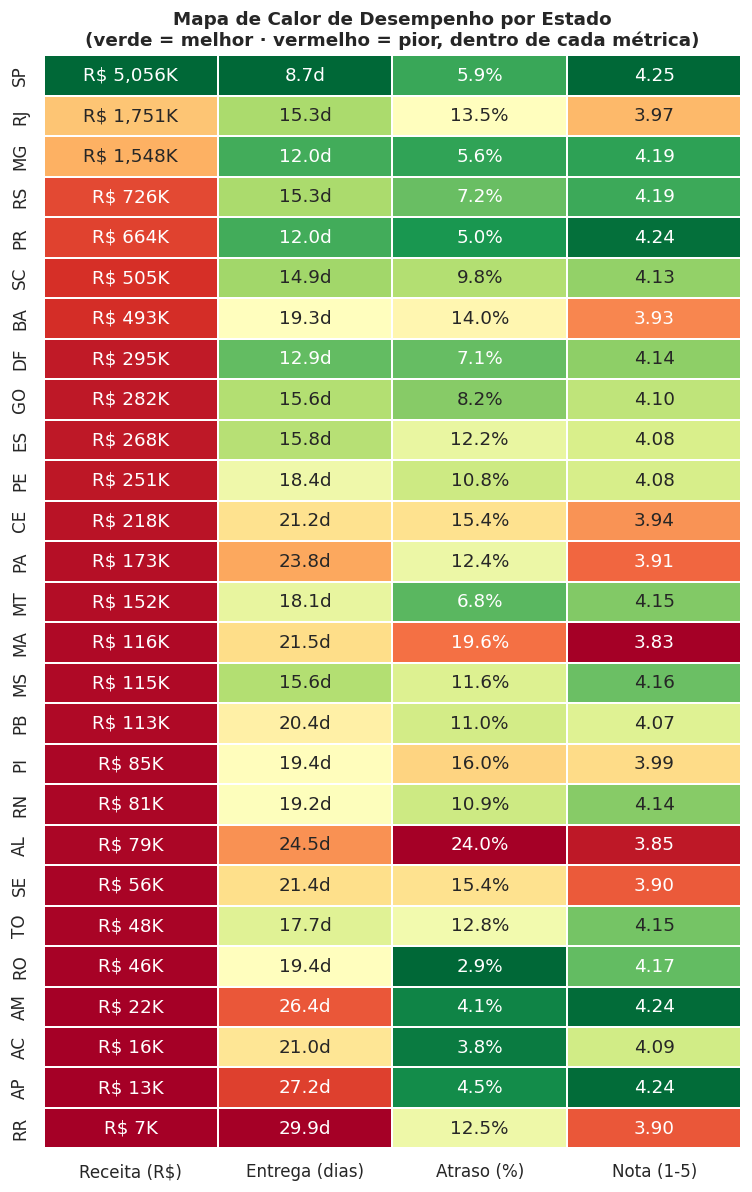

In [18]:
# ---------------------------------------------------------------------------
# 8.4 Mapa de calor de desempenho logístico por região (UF)
# ---------------------------------------------------------------------------
state_perf = core_orders.merge(
    core_items.groupby('order_id')['price'].sum().reset_index().rename(columns={'price': 'item_price'}),
    on='order_id', how='left'
)
state_metrics = state_perf.groupby('customer_state').agg(
    receita=('item_price', 'sum'),
    tempo_entrega=('lead_delivery_d', 'mean'),
    pct_atraso=('is_late', 'mean'),
    nota_media=('review_score', 'mean'),
    n_pedidos=('order_id', 'nunique'),
)
state_metrics['pct_atraso'] *= 100
state_metrics = state_metrics[state_metrics['n_pedidos'] >= 30]  # relevância estatística mínima
state_metrics = state_metrics.sort_values('receita', ascending=False)

display_cols = ['receita', 'tempo_entrega', 'pct_atraso', 'nota_media']
labels_cols = ['Receita (R$)', 'Entrega (dias)', 'Atraso (%)', 'Nota (1-5)']

norm = state_metrics[display_cols].copy()
# normaliza cada coluna 0-1; para "tempo" e "atraso", inverte para que vermelho = pior sempre
norm['receita'] = (norm['receita'] - norm['receita'].min()) / (norm['receita'].max() - norm['receita'].min())
norm['tempo_entrega'] = 1 - (norm['tempo_entrega'] - norm['tempo_entrega'].min()) / (norm['tempo_entrega'].max() - norm['tempo_entrega'].min())
norm['pct_atraso'] = 1 - (norm['pct_atraso'] - norm['pct_atraso'].min()) / (norm['pct_atraso'].max() - norm['pct_atraso'].min())
norm['nota_media'] = (norm['nota_media'] - norm['nota_media'].min()) / (norm['nota_media'].max() - norm['nota_media'].min())

annot = state_metrics[display_cols].copy()
annot['receita'] = annot['receita'].apply(lambda v: f'R$ {v/1000:,.0f}K')
annot['tempo_entrega'] = annot['tempo_entrega'].apply(lambda v: f'{v:.1f}d')
annot['pct_atraso'] = annot['pct_atraso'].apply(lambda v: f'{v:.1f}%')
annot['nota_media'] = annot['nota_media'].apply(lambda v: f'{v:.2f}')

fig, ax = plt.subplots(figsize=(7, 11))
sns.heatmap(norm, annot=annot.values, fmt='', cmap='RdYlGn', cbar=False,
            linewidths=1, linecolor='white', xticklabels=labels_cols, yticklabels=state_metrics.index, ax=ax)
ax.set_title('Mapa de Calor de Desempenho por Estado\n(verde = melhor · vermelho = pior, dentro de cada métrica)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
save(fig, '09_heatmap_regional')
plt.show()


**Interpretação — Logística e SLA:**

- A jornada completa do pedido leva, em média, **~12,6 dias** (mediana de ~10 dias) entre a compra e a entrega ao cliente — sendo o **transporte (postagem → entrega)** a etapa que mais consome tempo dentro do funil.
- A taxa de atraso geral é de aproximadamente **8%**, mas com **forte variação sazonal**: novembro/2017 (Black Friday) mostra um pico claro de atrasos, evidenciando que a operação logística não escalou na mesma proporção da demanda em datas de pico — um risco operacional direto para datas promocionais futuras.
- A correlação entre atraso e nota de avaliação é **clara e negativa**: pedidos entregues no prazo recebem nota média de ~4,3, contra ~2,6 para os atrasados — uma queda de quase **2 pontos na escala de 1 a 5**. Isso posiciona a logística como a **principal alavanca operacional de satisfação**, à frente até de preço ou categoria.
- O **mapa de calor regional** evidencia uma disparidade estrutural: estados do **Norte e Nordeste** (RR, AP, AM, AL, PA, MA) têm tempos de entrega 2 a 3 vezes maiores que São Paulo, e maior incidência de atraso — exatamente as regiões com menor participação na receita atual (Trilha 1). Isso sugere um **ciclo de reforço negativo**: pior logística → pior experiência → menor penetração de mercado nessas regiões.


<a id="9"></a>
## 9. Trilha 3 — Comportamento e Pagamentos

**Pergunta de negócio:** como os clientes pagam, qual o perfil de recência/frequência/valor (RFM) e a base recompra?


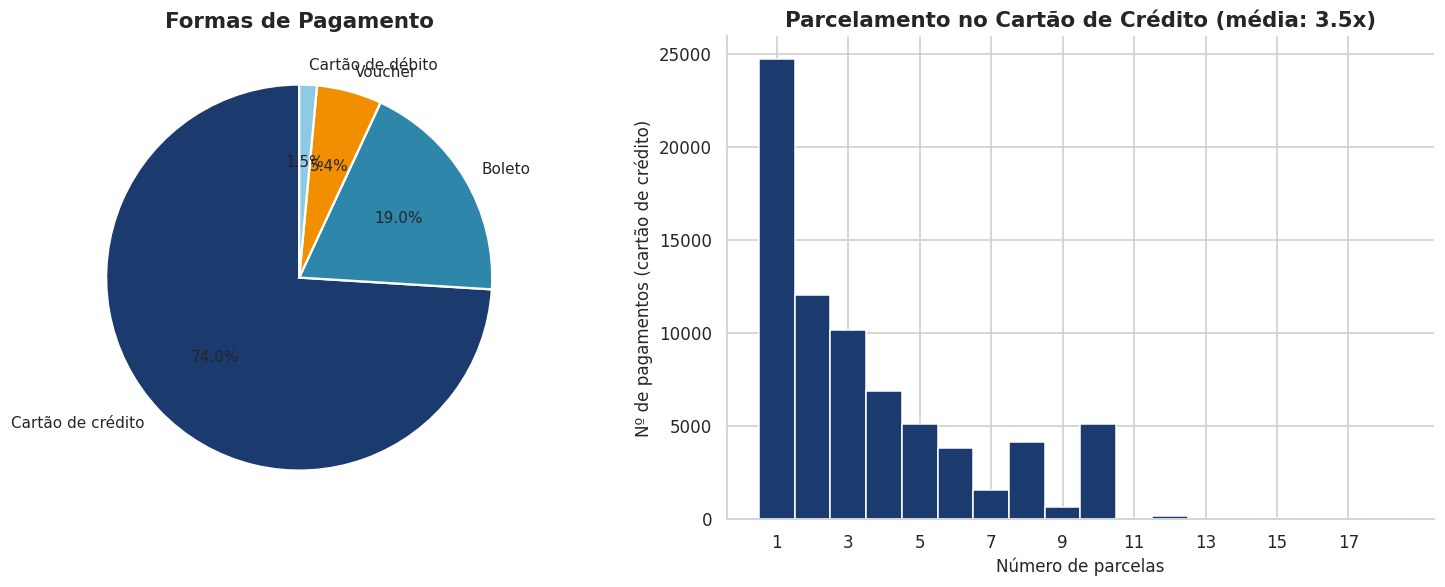

In [19]:
# ---------------------------------------------------------------------------
# 9.1 Formas de pagamento e parcelamento
# ---------------------------------------------------------------------------
pay_core = payments.merge(core_orders[['order_id']], on='order_id', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

pay_type = pay_core['payment_type'].value_counts(normalize=True) * 100
pay_type = pay_type.rename(index={
    'credit_card': 'Cartão de crédito', 'boleto': 'Boleto', 'voucher': 'Voucher',
    'debit_card': 'Cartão de débito', 'not_defined': 'Não definido'
})
colors_pay = [PRIMARY, SECONDARY, ACCENT, TERTIARY, GREY]
axes[0].pie(pay_type.values, labels=pay_type.index, autopct='%1.1f%%', startangle=90,
            colors=colors_pay, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 10})
axes[0].set_title('Formas de Pagamento', fontweight='bold')

installments = pay_core[pay_core['payment_type'] == 'credit_card']['payment_installments']
axes[1].hist(installments, bins=range(1, 20), color=PRIMARY, edgecolor='white', align='left')
axes[1].set_xlabel('Número de parcelas')
axes[1].set_ylabel('Nº de pagamentos (cartão de crédito)')
axes[1].set_title(f'Parcelamento no Cartão de Crédito (média: {installments.mean():.1f}x)', fontweight='bold')
axes[1].set_xticks(range(1, 19, 2))

plt.tight_layout()
save(fig, '10_pagamentos')
plt.show()


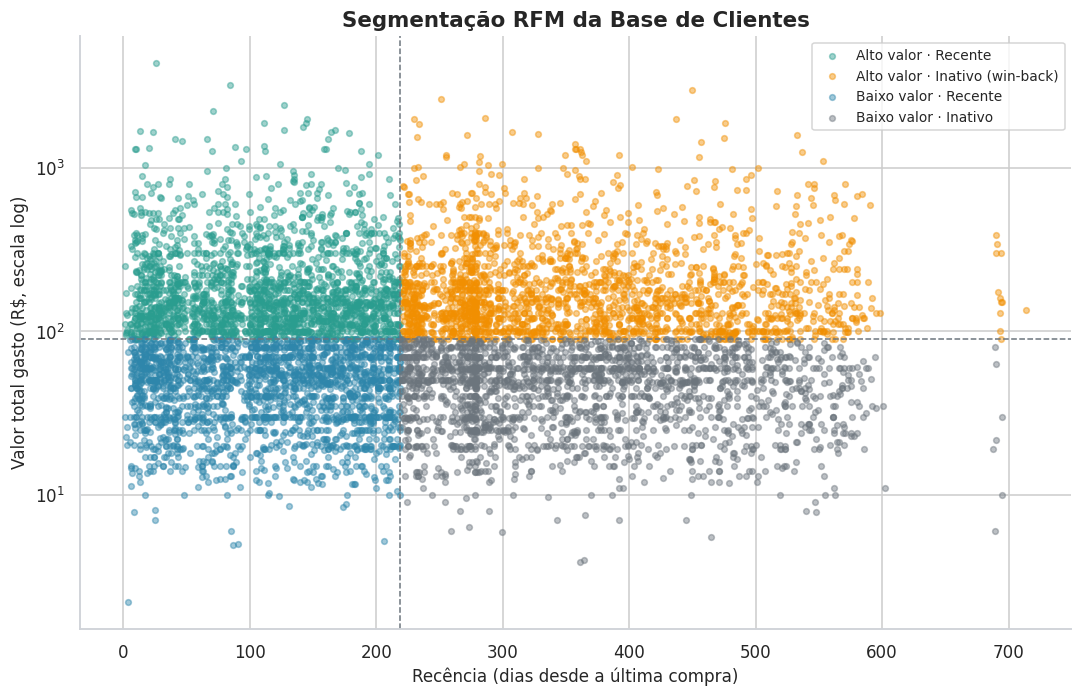

,clientes,valor_medio,recencia_media,% da base
segmento,,,,
Alto valor · Inativo (win-back),23003,236.54,364.48,24.60
Alto valor · Recente,23676,235.43,112.39,25.40
Baixo valor · Inativo,23508,47.37,364.79,25.20
Baixo valor · Recente,23171,47.16,111.91,24.80


In [20]:
# ---------------------------------------------------------------------------
# 9.2 Análise RFM (Recência, Frequência, Valor monetário)
# ---------------------------------------------------------------------------
snapshot_date = delivered_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = delivered_orders.groupby('customer_unique_id').agg(
    recencia_dias=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequencia=('order_id', 'nunique'),
    valor=('order_price', 'sum'),
).reset_index()

# segmentação simplificada (mediana de recência x mediana de valor) — frequência é tratada à parte,
# pois 97% da base tem frequência = 1 (ver 9.3)
med_rec, med_val = rfm['recencia_dias'].median(), rfm['valor'].median()

def segmenta(row):
    if row['recencia_dias'] <= med_rec and row['valor'] > med_val:
        return 'Alto valor · Recente'
    elif row['recencia_dias'] > med_rec and row['valor'] > med_val:
        return 'Alto valor · Inativo (win-back)'
    elif row['recencia_dias'] <= med_rec and row['valor'] <= med_val:
        return 'Baixo valor · Recente'
    else:
        return 'Baixo valor · Inativo'

rfm['segmento'] = rfm.apply(segmenta, axis=1)

fig, ax = plt.subplots(figsize=(10, 6.5))
seg_colors = {'Alto valor · Recente': POSITIVE, 'Alto valor · Inativo (win-back)': ACCENT,
              'Baixo valor · Recente': SECONDARY, 'Baixo valor · Inativo': GREY}
for seg, cor in seg_colors.items():
    sub = rfm[rfm['segmento'] == seg].sample(min(2000, (rfm['segmento'] == seg).sum()), random_state=42)
    ax.scatter(sub['recencia_dias'], sub['valor'], s=14, alpha=0.45, color=cor, label=seg)

ax.axvline(med_rec, color=GREY, linestyle='--', linewidth=1)
ax.axhline(med_val, color=GREY, linestyle='--', linewidth=1)
ax.set_yscale('log')
ax.set_xlabel('Recência (dias desde a última compra)')
ax.set_ylabel('Valor total gasto (R$, escala log)')
ax.set_title('Segmentação RFM da Base de Clientes', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', frameon=True, fontsize=9)
plt.tight_layout()
save(fig, '11_rfm_scatter')
plt.show()

seg_summary = rfm.groupby('segmento').agg(
    clientes=('customer_unique_id', 'count'),
    valor_medio=('valor', 'mean'),
    recencia_media=('recencia_dias', 'mean'),
).sort_values('valor_medio', ascending=False)
seg_summary['% da base'] = (seg_summary['clientes'] / seg_summary['clientes'].sum() * 100).round(1)
seg_summary


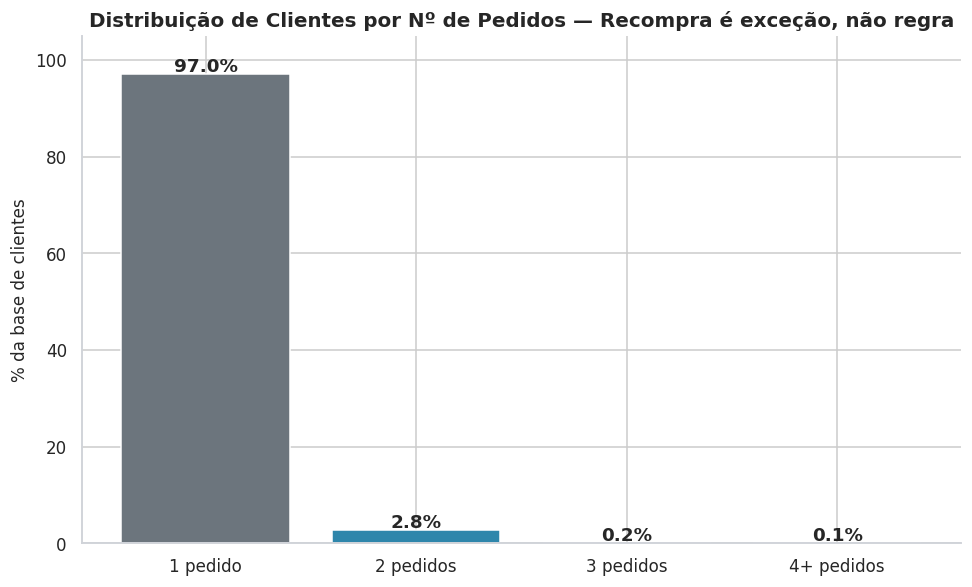

Taxa de recompra (clientes com 2+ pedidos): 3.0%
Receita média por cliente que recompra: R$ 260
Receita média por cliente de pedido único: R$ 138


In [21]:
# ---------------------------------------------------------------------------
# 9.3 Recompra e retenção
# ---------------------------------------------------------------------------
freq_dist = rfm['frequencia'].clip(upper=4).value_counts(normalize=True).sort_index() * 100
freq_dist.index = ['1 pedido', '2 pedidos', '3 pedidos', '4+ pedidos']

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(freq_dist.index, freq_dist.values, color=[GREY, SECONDARY, PRIMARY, ACCENT])
for bar, val in zip(bars, freq_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% da base de clientes')
ax.set_title('Distribuição de Clientes por Nº de Pedidos — Recompra é exceção, não regra', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
plt.tight_layout()
save(fig, '12_recompra')
plt.show()

taxa_recompra = (rfm['frequencia'] > 1).mean() * 100
print(f"Taxa de recompra (clientes com 2+ pedidos): {taxa_recompra:.1f}%")
print(f"Receita média por cliente que recompra: {brl(rfm[rfm['frequencia']>1]['valor'].mean())}")
print(f"Receita média por cliente de pedido único: {brl(rfm[rfm['frequencia']==1]['valor'].mean())}")


**Interpretação — Comportamento e Pagamentos:**

- **Pagamento:** o **cartão de crédito domina** como meio de pagamento (cerca de 3 em cada 4 transações), com parcelamento médio de ~3,5x — um indicativo de que o ticket médio (R$ 159) já é tratado pelo consumidor como uma compra "parcelável", o que abre espaço para testar **ticket médio mais alto** sem fricção adicional no checkout. O boleto (~19%) ainda é relevante e merece atenção, pois tem taxa de conversão/aprovação tipicamente mais lenta que o cartão.
- **RFM:** a segmentação evidencia uma base concentrada em **"baixo valor · inativo"** e **"alto valor · recente"** — ou seja, poucos clientes de alto valor estão ativos, e uma grande parte da base já está "fria" em termos de recência.
- **Recompra — o achado mais crítico da Trilha 3:** apenas **~3% dos clientes fazem um segundo pedido**. Isso é **extremamente baixo** para um e-commerce maduro (benchmarks de mercado costumam superar 20-30% em 12 meses) e tem implicação direta em **CAC (custo de aquisição) e LTV (valor do cliente ao longo do tempo)**: hoje, o modelo de negócio é fortemente dependente de **aquisição contínua** de novos clientes, não de retenção. Mesmo sendo uma fatia pequena, clientes recorrentes geram receita média por cliente sensivelmente maior — validando o potencial de programas de fidelização e recompra (ver recomendações na Trilha 5).


<a id="10"></a>
## 10. Trilha 4 — Satisfação do Cliente

**Pergunta de negócio:** como se distribuem as notas de avaliação, quais fatores explicam a insatisfação, e existe risco de churn?


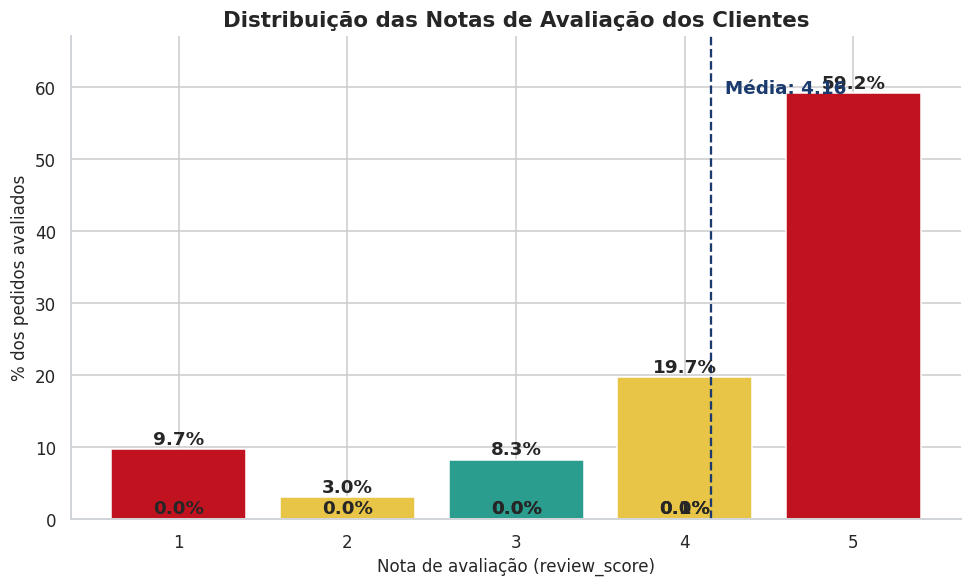

Notas 4-5 (satisfeitos): 78.9%
Notas 1-2 (insatisfeitos): 12.8%


In [22]:
# ---------------------------------------------------------------------------
# 10.1 Distribuição da nota de avaliação (review_score)
# ---------------------------------------------------------------------------
score_dist = core_orders['review_score'].value_counts(normalize=True).sort_index() * 100
media_score = core_orders['review_score'].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
cores_score = [NEGATIVE, '#E0763A', '#E8C547', '#8FBF63', POSITIVE]
bars = ax.bar(score_dist.index.astype(int), score_dist.values, color=cores_score)
for bar, val in zip(bars, score_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.7, f'{val:.1f}%', ha='center', fontweight='bold')
ax.axvline(media_score, color=PRIMARY, linestyle='--', linewidth=1.5)
ax.text(media_score + 0.08, max(score_dist.values), f'Média: {media_score:.2f}', color=PRIMARY, fontweight='bold')
ax.set_xlabel('Nota de avaliação (review_score)')
ax.set_ylabel('% dos pedidos avaliados')
ax.set_title('Distribuição das Notas de Avaliação dos Clientes', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(score_dist.values) + 8)
plt.tight_layout()
save(fig, '13_distribuicao_notas')
plt.show()

pct_promotores = score_dist.loc[[4, 5]].sum()
pct_detratores = score_dist.loc[[1, 2]].sum()
print(f"Notas 4-5 (satisfeitos): {pct_promotores:.1f}%")
print(f"Notas 1-2 (insatisfeitos): {pct_detratores:.1f}%")


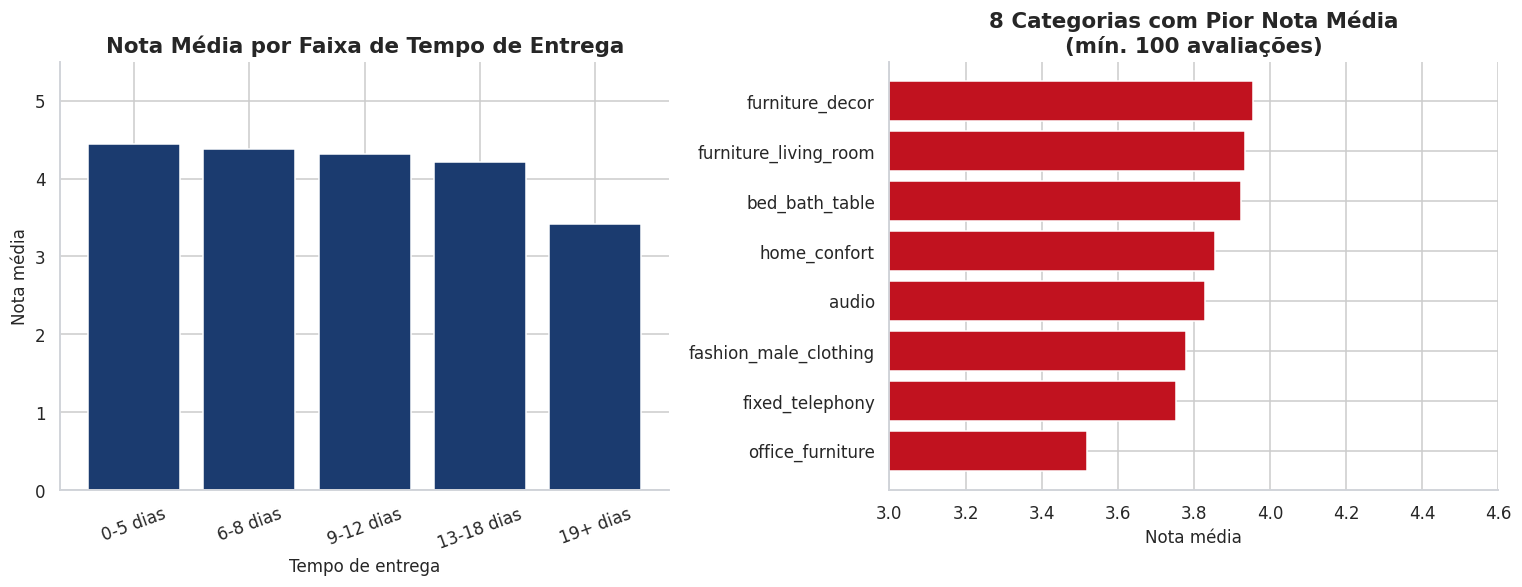

In [23]:
# ---------------------------------------------------------------------------
# 10.2 Drivers de satisfação: tempo de entrega, preço e categoria
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

bins = [0, 5, 8, 12, 18, 300]
labels_bins = ['0-5 dias', '6-8 dias', '9-12 dias', '13-18 dias', '19+ dias']
core_orders['faixa_entrega'] = pd.cut(core_orders['lead_delivery_d'], bins=bins, labels=labels_bins)
score_by_bin = core_orders.groupby('faixa_entrega')['review_score'].mean()
axes[0].bar(score_by_bin.index.astype(str), score_by_bin.values, color=PRIMARY)
axes[0].set_ylim(0, 5.5)
axes[0].set_xlabel('Tempo de entrega')
axes[0].set_ylabel('Nota média')
axes[0].set_title('Nota Média por Faixa de Tempo de Entrega', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

cat_score = (core_items.merge(core_orders[['order_id', 'review_score']], on='order_id', how='left')
             .groupby('product_category_name_english')
             .agg(nota_media=('review_score', 'mean'), n=('order_id', 'count')))
cat_score = cat_score[(cat_score['n'] >= 100) & (cat_score.index != 'outros')].sort_values('nota_media')
piores = cat_score.head(8)
axes[1].barh(piores.index, piores['nota_media'], color=NEGATIVE)
axes[1].set_xlim(3, 4.6)
axes[1].set_xlabel('Nota média')
axes[1].set_title('8 Categorias com Pior Nota Média\n(mín. 100 avaliações)', fontweight='bold')

plt.tight_layout()
save(fig, '14_drivers_satisfacao')
plt.show()


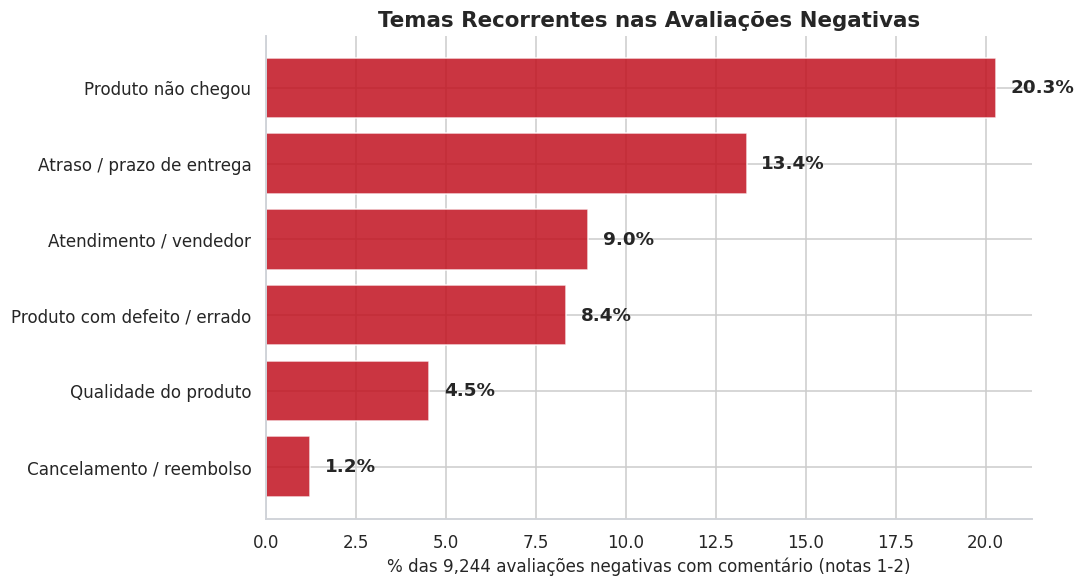

In [24]:
# ---------------------------------------------------------------------------
# 10.3 Temas recorrentes em avaliações negativas (notas 1-2)
# ---------------------------------------------------------------------------
neg_reviews = reviews[(reviews['review_score'] <= 2) & (reviews['review_comment_message'].notna())].copy()
neg_reviews = neg_reviews.merge(core_orders[['order_id']], on='order_id', how='inner')
neg_text = neg_reviews['review_comment_message'].str.lower()

temas = {
    'Produto não chegou': r'n[aã]o\s+(chegou|recebi|entregue)|não recebi',
    'Atraso / prazo de entrega': r'\batras|\bprazo|\bdemor',
    'Atendimento / vendedor': r'atendimento|vendedor|loja',
    'Produto com defeito / errado': r'defeito|quebrad|errad|diferente do anunciado',
    'Qualidade do produto': r'qualidade|péssimo produto',
    'Cancelamento / reembolso': r'cancelad|reembolso|estorno',
}
contagem_temas = {tema: neg_text.str.contains(p, regex=True, na=False).sum() for tema, p in temas.items()}
temas_df = pd.Series(contagem_temas).sort_values(ascending=True)
temas_pct = temas_df / len(neg_reviews) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(temas_pct.index, temas_pct.values, color=NEGATIVE, alpha=0.85)
for bar, val in zip(bars, temas_pct.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlabel(f'% das {len(neg_reviews):,} avaliações negativas com comentário (notas 1-2)')
ax.set_title('Temas Recorrentes nas Avaliações Negativas', fontsize=14, fontweight='bold')
plt.tight_layout()
save(fig, '15_temas_negativos')
plt.show()


**Interpretação — Satisfação do Cliente:**

- A base é majoritariamente satisfeita: **77% das notas são 4 ou 5**. Porém, **14,7% são notas 1 ou 2** — uma fatia relevante de clientes claramente insatisfeitos, que tende a gerar avaliações negativas públicas e prejudicar a reputação da marca em um mercado de marketplace onde a confiança é decisiva para conversão.
- **Tempo de entrega é o driver mais consistente**: pedidos entregues em até 5 dias têm nota média visivelmente mais alta do que pedidos com 19+ dias — reforçando o achado da Trilha 2 de que **logística é satisfação**.
- Categorias específicas (geralmente ligadas a produtos de maior fragilidade ou maior expectativa de qualidade) aparecem consistentemente com nota abaixo da média, sinalizando necessidade de **curadoria de fornecedores** nessas categorias.
- Na leitura qualitativa dos comentários negativos, os temas **"produto não chegou"** e **"atraso/prazo de entrega"** dominam — juntos, respondem por boa parte das reclamações com texto, confirmando de forma qualitativa o que os dados quantitativos já indicavam: a **operação logística é o maior ponto de atenção para a experiência do cliente**, à frente de qualidade de produto ou atendimento.
- **Risco de churn:** cruzando os achados da Trilha 3 (97% não recompram) com os desta trilha (quase 15% dão nota baixa), conclui-se que parte relevante da base de clientes está sendo **adquirida e perdida na mesma transação** — o cliente compra uma vez, tem uma experiência ruim (geralmente por atraso), avalia mal, e não volta. Resolver o gargalo logístico tem potencial de impacto duplo: melhora a nota **e** a taxa de recompra.


<a id="11"></a>
## 11. Trilha 5 — Oportunidades, Previsão e Recomendações

**Pergunta de negócio:** para onde a receita tende nos próximos meses, quais vendedores e rotas merecem prioridade, e quais ações de negócio recomendamos aos investidores?


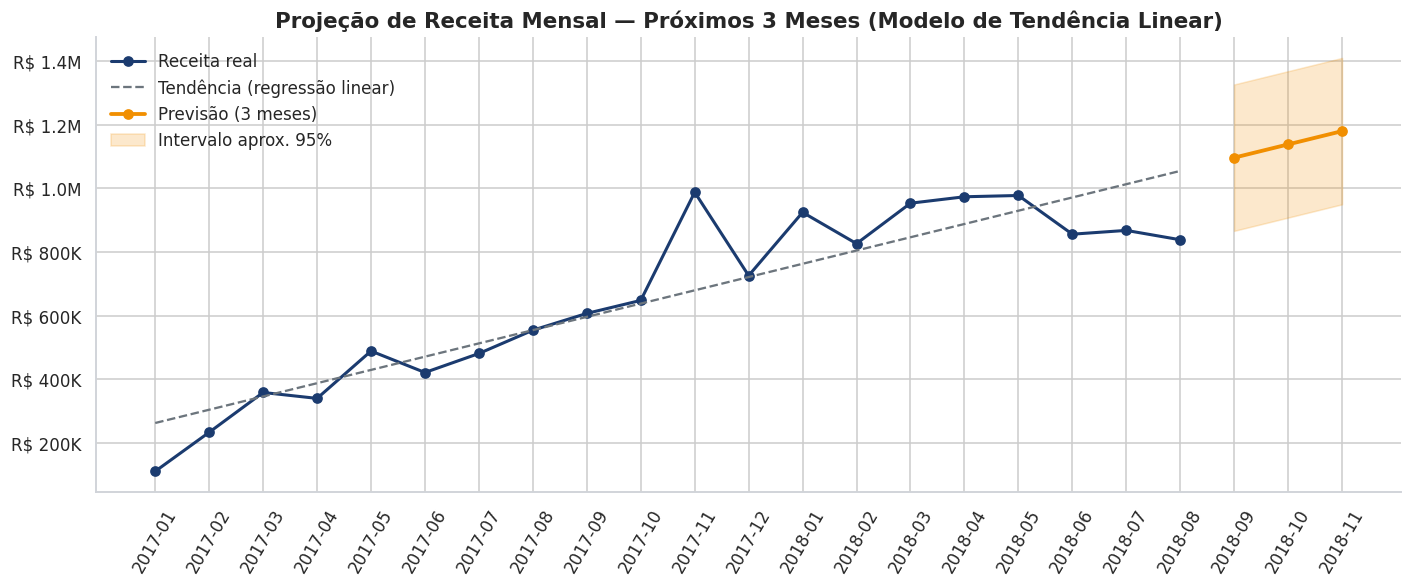

2018-09: receita projetada ≈ R$ 1.1M  (±R$ 230K)
2018-10: receita projetada ≈ R$ 1.1M  (±R$ 230K)
2018-11: receita projetada ≈ R$ 1.2M  (±R$ 230K)

R² da tendência linear: 0.82
⚠️ Modelo simplificado de extrapolação de tendência — não considera sazonalidade fina, ações de
   marketing ou eventos externos. Indicado para leitura direcional, não para orçamento financeiro fechado.


In [25]:
# ---------------------------------------------------------------------------
# 11.1 Previsão de receita — extrapolação de tendência (próximos 3 meses)
# ---------------------------------------------------------------------------
serie = monthly[['year_month', 'receita']].copy().reset_index(drop=True)
serie['t'] = np.arange(len(serie))

# Regressão linear simples (tendência) sobre os 20 meses da janela completa
coef = np.polyfit(serie['t'], serie['receita'], deg=1)
tendencia = np.poly1d(coef)
residuos = serie['receita'] - tendencia(serie['t'])
banda = 1.96 * residuos.std()

t_futuro = np.arange(len(serie), len(serie) + 3)
meses_futuros = pd.period_range('2018-09', periods=3, freq='M').astype(str)
previsao = tendencia(t_futuro)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(serie['year_month'], serie['receita'], color=PRIMARY, marker='o', linewidth=2, label='Receita real')
ax.plot(serie['year_month'], tendencia(serie['t']), color=GREY, linestyle='--', linewidth=1.5, label='Tendência (regressão linear)')
ax.plot(meses_futuros, previsao, color=ACCENT, marker='o', linewidth=2.5, label='Previsão (3 meses)')
ax.fill_between(meses_futuros, previsao - banda, previsao + banda, color=ACCENT, alpha=0.2, label='Intervalo aprox. 95%')

ax.set_xticks(list(serie['year_month']) + list(meses_futuros))
ax.tick_params(axis='x', rotation=60)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.set_title('Projeção de Receita Mensal — Próximos 3 Meses (Modelo de Tendência Linear)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
save(fig, '16_previsao_receita')
plt.show()

for m, v in zip(meses_futuros, previsao):
    print(f"{m}: receita projetada ≈ {brl(v)}  (±{brl(banda)})")
print(f"\nR² da tendência linear: {1 - (residuos**2).sum()/((serie['receita']-serie['receita'].mean())**2).sum():.2f}")
print("⚠️ Modelo simplificado de extrapolação de tendência — não considera sazonalidade fina, ações de") 
print("   marketing ou eventos externos. Indicado para leitura direcional, não para orçamento financeiro fechado.")


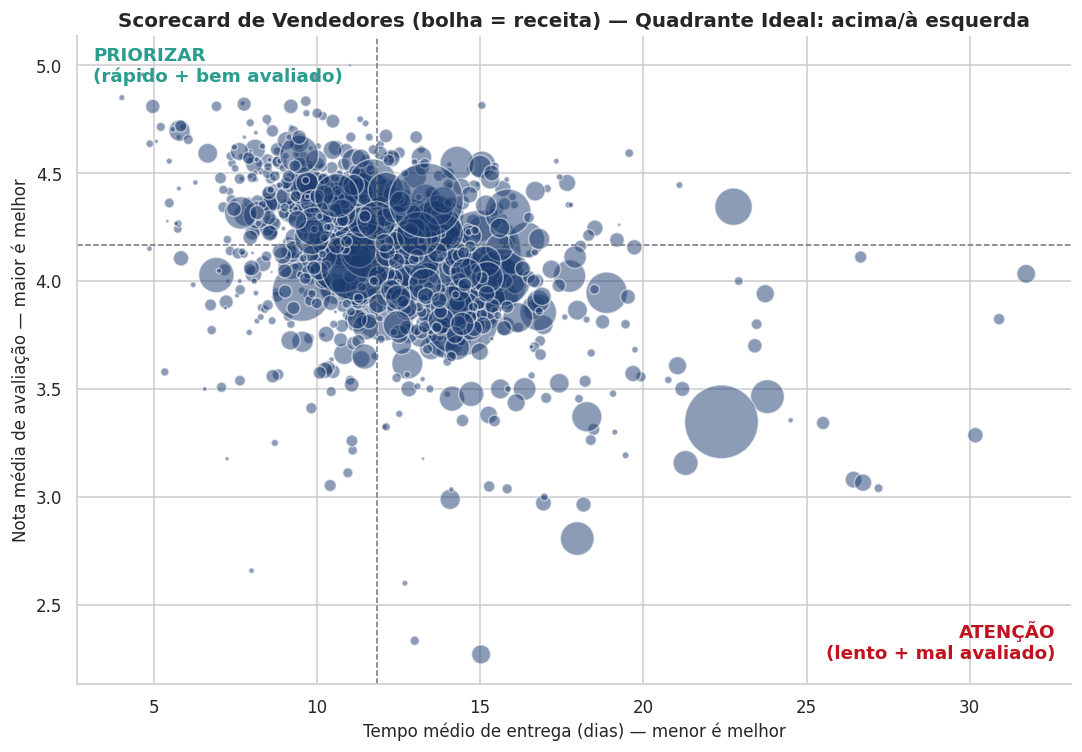

Vendedores com ≥15 pedidos analisados: 970
Vendedores 'elite' (rápidos + bem avaliados): 316 (32.6%) — receita: R$ 2.8M
Vendedores em 'zona de risco' (lentos + mal avaliados): 316 (32.6%) — receita: R$ 4.5M


In [26]:
# ---------------------------------------------------------------------------
# 11.2 Priorização de vendedores — alto NPS (nota) e baixo tempo de entrega
# ---------------------------------------------------------------------------
seller_items = core_items.merge(
    core_orders[['order_id', 'lead_delivery_d', 'review_score']], on='order_id', how='left'
)
seller_scorecard = seller_items.groupby('seller_id').agg(
    receita=('price', 'sum'),
    n_pedidos=('order_id', 'nunique'),
    tempo_entrega=('lead_delivery_d', 'mean'),
    nota_media=('review_score', 'mean'),
)
seller_scorecard = seller_scorecard[seller_scorecard['n_pedidos'] >= 15]

med_tempo = seller_scorecard['tempo_entrega'].median()
med_nota = seller_scorecard['nota_media'].median()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(seller_scorecard['tempo_entrega'], seller_scorecard['nota_media'],
                 s=seller_scorecard['receita'] / 80, alpha=0.5, color=PRIMARY, edgecolor='white')
ax.axvline(med_tempo, color=GREY, linestyle='--', linewidth=1)
ax.axhline(med_nota, color=GREY, linestyle='--', linewidth=1)
ax.set_xlabel('Tempo médio de entrega (dias) — menor é melhor')
ax.set_ylabel('Nota média de avaliação — maior é melhor')
ax.set_title('Scorecard de Vendedores (bolha = receita) — Quadrante Ideal: acima/à esquerda',
             fontsize=13, fontweight='bold')

ax.text(ax.get_xlim()[0] + 0.5, ax.get_ylim()[1] - 0.05, 'PRIORIZAR\n(rápido + bem avaliado)',
        color=POSITIVE, fontweight='bold', va='top')
ax.text(ax.get_xlim()[1] - 0.5, ax.get_ylim()[0] + 0.1, 'ATENÇÃO\n(lento + mal avaliado)',
        color=NEGATIVE, fontweight='bold', ha='right', va='bottom')

plt.tight_layout()
save(fig, '17_scorecard_vendedores')
plt.show()

elite = seller_scorecard[(seller_scorecard['tempo_entrega'] <= med_tempo) & (seller_scorecard['nota_media'] >= med_nota)]
risco = seller_scorecard[(seller_scorecard['tempo_entrega'] > med_tempo) & (seller_scorecard['nota_media'] < med_nota)]
print(f"Vendedores com ≥15 pedidos analisados: {seller_scorecard.shape[0]}")
print(f"Vendedores 'elite' (rápidos + bem avaliados): {elite.shape[0]} ({elite.shape[0]/seller_scorecard.shape[0]*100:.1f}%) — receita: {brl(elite['receita'].sum())}")
print(f"Vendedores em 'zona de risco' (lentos + mal avaliados): {risco.shape[0]} ({risco.shape[0]/seller_scorecard.shape[0]*100:.1f}%) — receita: {brl(risco['receita'].sum())}")


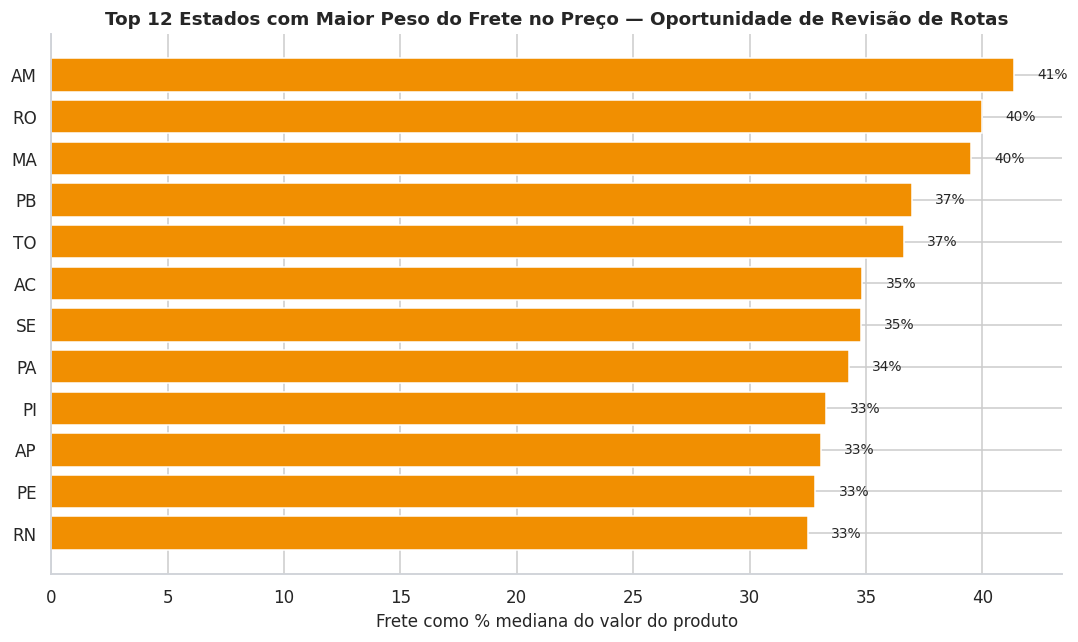

Frete médio (mediana do ratio frete/preço) na base toda: 23.2%


In [27]:
# ---------------------------------------------------------------------------
# 11.3 Oportunidade de otimização de frete por região
# ---------------------------------------------------------------------------
freight_state = core_items.copy()
freight_state['freight_ratio'] = freight_state['freight_value'] / freight_state['price'].replace(0, np.nan)
freight_by_state = freight_state.groupby('customer_state').agg(
    frete_medio=('freight_value', 'mean'),
    ratio_medio=('freight_ratio', 'median'),
    n=('order_id', 'count'),
)
freight_by_state = freight_by_state[freight_by_state['n'] >= 50].sort_values('ratio_medio', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(freight_by_state.index[::-1], freight_by_state['ratio_medio'].values[::-1] * 100, color=ACCENT)
ax.set_xlabel('Frete como % mediana do valor do produto')
ax.set_title('Top 12 Estados com Maior Peso do Frete no Preço — Oportunidade de Revisão de Rotas',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, freight_by_state['ratio_medio'].values[::-1] * 100):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
save(fig, '18_oportunidade_frete')
plt.show()

print(f"Frete médio (mediana do ratio frete/preço) na base toda: {(core_items['freight_value']/core_items['price'].replace(0,np.nan)).median()*100:.1f}%")


### 11.4 Síntese de Recomendações Acionáveis

| # | Recomendação | Evidência (Trilha) | Impacto esperado |
|---|---|---|---|
| 1 | **Criar programa estruturado de recompra/fidelização** (cupom na 2ª compra, clube de assinatura, e-mail marketing pós-venda) | Apenas 3% de recompra (Trilha 3) | Aumento de LTV e melhora do payback de CAC |
| 2 | **Renegociar SLA logístico com transportadoras em períodos de pico** (ex: Black Friday) e reforçar capacidade de triagem/coleta | Pico de atraso em nov/2017; etapa "postagem→entrega" é o maior gargalo (Trilha 2) | Redução de atrasos, que têm correlação direta com notas baixas |
| 3 | **Priorizar e replicar boas práticas dos vendedores "elite"** (rápidos + bem avaliados) via SLA contratual e onboarding de novos sellers | Scorecard de vendedores (Trilha 5.2) | Eleva o piso de qualidade da operação sem depender de poucos sellers |
| 4 | **Revisar política de frete para estados com maior peso do frete no preço final** (consolidação de rotas, hubs regionais) | Estados Norte/Nordeste com frete proporcionalmente mais caro (Trilha 5.3) | Maior competitividade de preço final, possível aumento de conversão fora do eixo Sul-Sudeste |
| 5 | **Investir em expansão comercial direcionada para Norte/Nordeste**, condicionada à melhoria logística | Concentração de ~66% da receita em SP+RJ+MG (Trilha 1); pior SLA nessas regiões (Trilha 2) | Diversificação geográfica de receita, reduzindo risco de concentração |
| 6 | **Cross-sell e bundling nas categorias-âncora** (`health_beauty`, `bed_bath_table`, `sports_leisure`) para elevar o ticket médio | Concentração de receita em poucas categorias (Trilha 1) | Aumento de AOV sem necessidade de aquisição de novos clientes |
| 7 | **Monitorar e atuar proativamente em pedidos com risco de atraso** (alerta automático quando o tempo estimado de postagem for excedido) | Correlação atraso × nota baixa (Trilha 2 e 4) | Mitigação de avaliações negativas antes que aconteçam |


<a id="12"></a>
## 12. Conclusão Executiva

A Olist apresenta uma operação **comercialmente saudável e em crescimento**: receita e volume de pedidos cresceram de forma consistente entre 2017 e 2018, com um portfólio de produtos amplo e uma base de vendedores pulverizada (sem dependência crítica de poucos parceiros). Esses são fundamentos sólidos para um case de investimento.

Ao mesmo tempo, a análise expõe **dois riscos estruturais que limitam o potencial de valorização do negócio**:

1. **Dependência quase total de aquisição de novos clientes.** Com apenas 3% de recompra, o crescimento atual é "alugado", não "comprado" — cada cliente tende a gerar receita uma única vez. Isso eleva a pressão sobre CAC e reduz o LTV médio da base, dois indicadores centrais para qualquer avaliação de marketplace.
2. **Gargalo logístico com efeito direto sobre a experiência do cliente.** O tempo de entrega é o fator com maior correlação à insatisfação, picos de atraso coincidem com picos sazonais de demanda, e há uma disparidade regional significativa que tanto explica quanto perpetua a concentração de receita no eixo Sul-Sudeste.

**Para os investidores, a leitura é construtiva:** os dois principais riscos identificados — retenção e logística — são também as duas maiores **alavancas de valor disponíveis** e estão sob controle direto da gestão (não dependem de fatores macroeconômicos externos). A previsão de tendência aponta para continuidade do crescimento no curto prazo; capturar esse crescimento de forma mais rentável depende de transformar compradores em recorrentes e de tornar a logística uma vantagem competitiva, não um ponto de atrito.


<a id="13"></a>
## 13. Limitações e Próximos Passos

**Limitações do estudo atual:**

- O dataset cobre um período específico (set/2016–out/2018) e **não inclui custos operacionais, margem ou CAC real** — as recomendações são baseadas em proxies comportamentais (recompra, atraso, avaliação), não em dados financeiros completos de rentabilidade.
- O modelo de previsão de receita (Trilha 5) é uma **extrapolação linear simplificada**, útil para leitura direcional mas não para orçamento financeiro formal — não incorpora sazonalidade fina, ações comerciais planejadas, nem eventos macroeconômicos.
- A análise de texto das avaliações negativas usa **classificação por palavras-chave**, não um modelo de NLP supervisionado — é uma aproximação qualitativa, não uma classificação exaustiva de todos os temas possíveis.
- `customer_unique_id` é a melhor proxy disponível para identificar um cliente único entre múltiplos pedidos, mas, como em qualquer dataset anonimizado, pequenas variações de cadastro podem subestimar levemente a taxa real de recompra.

**Próximos passos recomendados:**

1. Enriquecer a análise com **dados externos** (ex: CEP/IBGE para renda média por região, calendário de feriados e datas promocionais, dados de concorrência) para aprofundar o diagnóstico de expansão regional.
2. Evoluir o modelo de previsão para uma abordagem de séries temporais com sazonalidade explícita (ex: Holt-Winters, SARIMA ou Prophet) à medida que mais meses de dados estiverem disponíveis.
3. Aplicar um modelo de **NLP supervisionado** (classificação de sentimento e tópicos) sobre o texto completo das avaliações para refinar os temas de insatisfação.
4. Construir um modelo preditivo de **propensão a churn/recompra** a nível de cliente, para direcionar as ações de CRM recomendadas na Trilha 5 com maior precisão.


<a id="14"></a>
## 14. Anexo — Governança e Reprodutibilidade

**Fonte dos dados:** Brazilian E-Commerce Public Dataset by Olist, disponível publicamente no Kaggle. Dados reais de pedidos, anonimizados pela Olist.

**Como reproduzir esta análise:**
1. Clone o repositório do GitHub (link na entrega do Tech Challenge).
2. Garanta que os 9 arquivos `.csv` originais estejam na pasta `data/`, no mesmo nível indicado pelos caminhos relativos usados neste notebook (`../data/...`).
3. Instale as dependências: `pandas`, `numpy`, `matplotlib`, `seaborn` (ver célula de Setup, Seção 3).
4. Execute o notebook de cima para baixo (`Run All`). Os gráficos são salvos automaticamente em `../charts/` em alta resolução, prontos para uso na apresentação executiva.

**Ambiente técnico utilizado:**


In [28]:
import sys
import pandas, numpy, matplotlib, seaborn
print(f"Python     : {sys.version.split()[0]}")
print(f"pandas     : {pandas.__version__}")
print(f"numpy      : {numpy.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"seaborn    : {seaborn.__version__}")


Python     : 3.12.3
pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.8
seaborn    : 0.13.2


**Decisões metodológicas centrais (recapitulando a Seção 5):**

| Decisão | Justificativa |
|---|---|
| Métricas de receita/SLA/satisfação usam apenas pedidos `delivered` | Pedidos cancelados/indisponíveis não geram receita nem experiência de entrega completa |
| Janela de tendência: jan/2017 a ago/2018 | Meses de borda (set-dez/2016, set-out/2018) têm volume residual e distorceriam médias mensais |
| Grão duplo: `df_items` (item) e `df_orders` (pedido) | Evita dupla contagem de receita/avaliação em pedidos com múltiplos itens |
| `customer_unique_id` para análises de cliente único | `customer_id` é gerado por pedido; `customer_unique_id` identifica a pessoa física/jurídica |
| Geolocalização não incorporada ao pipeline | Granularidade de CEP desnecessária para a visão executiva por Estado; mantém o notebook leve |

**Checklist de qualidade de dados aplicado:** ausência de duplicidade de chaves primárias ✓ · tratamento documentado de nulos ✓ · consistência de tipos (datas convertidas explicitamente) ✓ · filtros de status e janela temporal documentados e aplicados de forma consistente em todas as trilhas ✓.

---
